# Toki DPD91 Prediction

## Data Scientist Candidate Assignment

Энэхүү notebook-ийн зорилго нь Toki-ийн credit card үйлчилгээний 31 хоногийн хугацаа хэтрүүлэлттэй (`DPD31`) зээлдэгч цаашид 91 хоног болон түүнээс дээш хугацаагаар хугацаа хэтрүүлэх (`DPD91+`) эсэхийг таамаглах Machine Learning model боловсруулахад оршино.

Шинжилгээг хийхдээ өгөгдлийн чанар, feature availability, Data Leakage, temporal validation, feature engineering, model selection болон final evaluation зэрэг үе шатуудыг дараалалтайгаар авч үзнэ.

Эцсийн зорилго нь зөвхөн өндөр predictive performance авах бус, тухайн model-ийн үр дүнг бизнесийн үйл ажиллагаанд хэрхэн ашиглаж болохыг тайлбарлах, мөн model-ийн хязгаарлалтыг тодорхойлох явдал юм.

## 1. Environment Setup

Энэ хэсэгт шинжилгээ болон Machine Learning model боловсруулахад шаардлагатай Python libraries-ийг импортолно.

Шинжилгээний явцад reproducibility-г хадгалахын тулд шаардлагатай тохиолдолд `random_state`-ийг тогтмол утгаар ашиглана.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading

Даалгаварт өгөгдөл Excel workbook хэлбэрээр өгөгдсөн бөгөөд workbook-ийн sheet-үүдэд credit card үйлчилгээний DPD31-тэй холбоотой мэдээлэл хадгалагдсан.

Эхний алхамд workbook-ийн бүх sheet-ийн нэр болон хэмжээтэй танилцаж, modeling-д ямар өгөгдөл ашиглахыг тодорхойлно.

Энэ шатанд өгөгдлийг шууд өөрчлөхгүй. Эхлээд эх өгөгдлийн бүтцийг шалгаж, дараагийн preprocessing алхмуудыг нотолгоонд үндэслэн тодорхойлно.

In [3]:
# Path to the provided Excel workbook
file_path = "../data/raw/Toki Data Scientist task.xlsx"

# Read workbook structure
excel_file = pd.ExcelFile(file_path)

print("Available sheets:")
for sheet in excel_file.sheet_names:
    print(f"- {sheet}")

Available sheets:
- Rule
- data_description
- payment
- overdue
- balance
- user_list


In [4]:
# Load all sheets without modifying the original data
data_sheets = {
    sheet: pd.read_excel(file_path, sheet_name=sheet)
    for sheet in excel_file.sheet_names
}

# Display basic information for each sheet
sheet_summary = []

for sheet_name, df in data_sheets.items():
    sheet_summary.append({
        "sheet": sheet_name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    })

sheet_summary = pd.DataFrame(sheet_summary)

sheet_summary

,sheet,rows,columns
0,Rule,16,2
1,data_description,97,3
2,payment,445910,3
3,overdue,710118,42
4,balance,884449,9
5,user_list,61200,43


In [5]:
# Preview the main user-level dataset
user_list = data_sheets["user_list"].copy()

print("user_list shape:", user_list.shape)
print("\nFirst 5 rows:")
display(user_list.head())

user_list shape: (61200, 43)

First 5 rows:


,created_month,date_dpd_31,credit_id,limit_dpd31,balance_dpd31,limit_ondue,balance_ondue,invoiced_unpaid_amt,total_payment_amt,ostype,liveness_cnt,liveness_success_cnt,liveness_forgetful_cnt,liveness_fail_cnt,user_tenure,profile_changed_since,has_changed_phone,gender,age,app_recency_days,trx_recency_l90d,trx_l7d,trx_l30d,trx_l60d,trx_l90d,avg_trx_amount_l7d,avg_trx_amount_l30d,avg_trx_amount_l60d,avg_trx_amount_l90d,sessions_l7d,sessions_l30d,sessions_l60d,sessions_l90d,read_noti_l7d,read_noti_l30d,read_noti_l60d,read_noti_l90d,is_unitel,number_change_cnt_l30d,number_change_cnt_l60d,number_change_cnt_l90d,number_change_cnt,is_dpd_91
0,202512,2025-12-16,2012138,183000.0,180989.12,183000,180989.12,48689.11,428300.00,2.0,3.0,3.0,1.0,0.0,1212.0,1093.0,1.0,1.0,28.0,62.0,69.0,0.0,0.0,0.0,10.0,NaN,NaN,NaN,100508.000000,0.0,0.0,0.0,12.0,0.0,0.0,0.0,12.0,1.0,0.0,0.0,0.0,4.0,1.0
1,202512,2025-12-16,2380667,344000.0,182053.88,344000,182053.88,49295.55,200051.06,1.0,2.0,1.0,1.0,0.0,361.0,280.0,0.0,2.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0
2,202512,2025-12-16,2485544,185000.0,170415.00,185000,170415.00,47003.90,28538.52,1.0,4.0,4.0,4.0,0.0,1212.0,641.0,0.0,1.0,22.0,1.0,46.0,0.0,0.0,1.0,1.0,NaN,NaN,28600.000000,3000.000000,3.0,10.0,4.0,11.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,202512,2025-12-16,2347184,300000.0,273594.00,300000,273594.00,57435.42,0.00,2.0,1.0,1.0,0.0,0.0,321.0,321.0,0.0,1.0,28.0,1.0,32.0,0.0,0.0,5.0,3.0,NaN,NaN,12600.000000,667.000000,1.0,3.0,15.0,4.0,5.0,5.0,0.0,11.0,1.0,0.0,0.0,0.0,1.0,0.0
4,202512,2025-12-16,2105376,302000.0,301703.92,302000,301703.92,82927.03,1349321.06,1.0,11.0,5.0,0.0,0.0,1212.0,625.0,0.0,1.0,28.0,18.0,19.0,0.0,10.0,23.0,12.0,NaN,2000.0,1956.521739,9733.333333,0.0,7.0,19.0,18.0,0.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 3. Dataset Audit

Model боловсруулахын өмнө өгөгдлийн үндсэн бүтэц болон чанарыг шалгана.

Энэ хэсэгт дараах асуултуудад хариулна:

- Dataset хэдэн observation болон feature-тэй вэ?
- Target variable ямар бүтэцтэй вэ?
- Labeled болон unlabeled observation хэд байна вэ?
- `credit_id` давтагдаж байна уу?
- Data type-ууд зөв тодорхойлогдсон уу?
- `created_month` болон `date_dpd_31` ямар хугацааны мэдээлэлтэй вэ?
- Target class imbalance хэр байна вэ?

Эдгээр шалгалтын үр дүн нь дараагийн preprocessing болон validation strategy-г тодорхойлоход ашиглагдана.

In [6]:
# ============================================================
# 3.1 Basic Dataset Structure
# ============================================================

print("Dataset shape:", user_list.shape)

print("\nColumn count:", len(user_list.columns))

print("\nData types:")
display(user_list.dtypes.to_frame("dtype"))

Dataset shape: (61200, 43)

Column count: 43

Data types:


,dtype
created_month,int64
date_dpd_31,datetime64[ns]
credit_id,int64
limit_dpd31,float64
balance_dpd31,float64
limit_ondue,int64
balance_ondue,float64
invoiced_unpaid_amt,float64
total_payment_amt,float64
ostype,float64


In [7]:
# ============================================================
# 3.2 Target Variable Audit
# ============================================================

target = "is_dpd_91"

print("Target:", target)

print("\nTarget value counts:")
display(user_list[target].value_counts(dropna=False).sort_index())

print("\nTarget missing values:")
print(user_list[target].isna().sum())

print("\nTarget missing rate:")
print(f"{user_list[target].isna().mean():.2%}")

Target: is_dpd_91

Target value counts:


is_dpd_91
0.0    36064
1.0    16673
NaN     8463
Name: count, dtype: int64


Target missing values:
8463

Target missing rate:
13.83%


In [8]:
# ============================================================
# 3.3 Labeled vs Unlabeled Observations
# ============================================================

labeled_mask = user_list[target].notna()
unlabeled_mask = user_list[target].isna()

labeled_count = labeled_mask.sum()
unlabeled_count = unlabeled_mask.sum()

print("Labeled observations:")
print(f"  Rows: {labeled_count:,}")
print(f"  Share: {labeled_count / len(user_list):.2%}")

print("\nUnlabeled observations:")
print(f"  Rows: {unlabeled_count:,}")
print(f"  Share: {unlabeled_count / len(user_list):.2%}")

Labeled observations:
  Rows: 52,737
  Share: 86.17%

Unlabeled observations:
  Rows: 8,463
  Share: 13.83%


,target,count,percentage
0,0.0,36064,0.683846
1,1.0,16673,0.316154


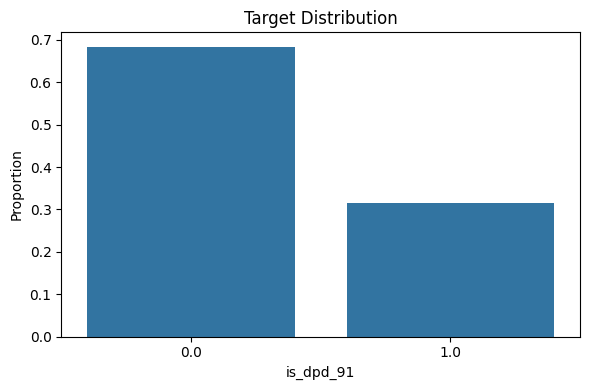

In [9]:
# ============================================================
# 3.4 Target Distribution
# ============================================================

target_distribution = (
    user_list.loc[labeled_mask, target]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / target_distribution["count"].sum()
)

display(target_distribution)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=target_distribution,
    x="target",
    y="percentage"
)

plt.title("Target Distribution")
plt.xlabel("is_dpd_91")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 3.5 Credit ID Audit
# ============================================================

credit_id = "credit_id"

total_rows = len(user_list)
unique_credits = user_list[credit_id].nunique()
duplicate_rows = total_rows - unique_credits

print(f"Total rows: {total_rows:,}")
print(f"Unique credit_id: {unique_credits:,}")
print(f"Rows beyond unique credit_id count: {duplicate_rows:,}")

print("\nDuplicated credit_id rows:")
print(f"{user_list[credit_id].duplicated(keep=False).sum():,}")

Total rows: 61,200
Unique credit_id: 46,516
Rows beyond unique credit_id count: 14,684

Duplicated credit_id rows:
27,289


In [13]:
# ============================================================
# 3.6 Credit ID Frequency
# ============================================================

credit_frequency = (
    user_list[credit_id]
    .value_counts()
    .rename("event_count")
)

print("Credit ID frequency distribution:")
display(credit_frequency.describe())

print("\nNumber of credits by event count:")
display(
    credit_frequency
    .value_counts()
    .sort_index()
    .head(20)
    .rename_axis("event_count")
    .reset_index(name="number_of_credits")
)

Credit ID frequency distribution:


count    46516.000000
mean         1.315676
std          0.559145
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          6.000000
Name: event_count, dtype: float64


Number of credits by event count:


,event_count,number_of_credits
0,1,33911
1,2,10685
2,3,1769
3,4,144
4,5,6
5,6,1


In [14]:
# ============================================================
# 3.7 Temporal Coverage
# ============================================================

print("created_month unique values:")
print(sorted(user_list["created_month"].dropna().unique()))

print("\nNumber of rows by created_month:")
display(
    user_list["created_month"]
    .value_counts()
    .sort_index()
    .rename_axis("created_month")
    .reset_index(name="row_count")
)

print("\ndate_dpd_31 range:")

date_dpd_31 = pd.to_datetime(user_list["date_dpd_31"], errors="coerce")

print("Minimum:", date_dpd_31.min())
print("Maximum:", date_dpd_31.max())
print("Missing:", date_dpd_31.isna().sum())

created_month unique values:
[np.int64(202512), np.int64(202601), np.int64(202602), np.int64(202603), np.int64(202604), np.int64(202605), np.int64(202606)]

Number of rows by created_month:


,created_month,row_count
0,202512,8796
1,202601,7846
2,202602,8733
3,202603,9775
4,202604,9263
5,202605,8943
6,202606,7844



date_dpd_31 range:
Minimum: 2025-12-16 00:00:00
Maximum: 2026-06-15 00:00:00
Missing: 0


In [15]:
# ============================================================
# 3.8 Missing Values Overview
# ============================================================

missing_summary = (
    user_list.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"] / len(user_list)
)

missing_summary = (
    missing_summary
    .sort_values("missing_rate", ascending=False)
)

display(missing_summary)

,missing_count,missing_rate
avg_trx_amount_l7d,52655,0.860376
avg_trx_amount_l30d,41502,0.678137
avg_trx_amount_l60d,21144,0.345490
avg_trx_amount_l90d,20073,0.327990
app_recency_days,11522,0.188268
sessions_l7d,11522,0.188268
sessions_l30d,11522,0.188268
sessions_l60d,11522,0.188268
sessions_l90d,11522,0.188268
read_noti_l7d,11522,0.188268


## 4. Prediction Point and Feature Availability

Энэ асуудлын prediction point нь зээлдэгч 31 хоногийн хугацаа хэтрүүлсэн буюу `DPD31`-д хүрсэн мөч юм.

`data_description`-ийн дагуу `date_dpd_31` нь тухайн зээлдэгч DPD31-д хүрсэн яг огноог илэрхийлдэг бөгөөд `user_list`-ийн бусад feature-үүд энэ огноог Day 0 буюу prediction cutoff point болгон ашигладаг.

Иймээс model-д ашиглах feature нь prediction хийх мөчид мэдэгдэж байсан мэдээллээр хязгаарлагдах ёстой.

Энэ шалгалтын үндсэн зорилго нь:

1. Prediction хийхэд шууд ашиглах боломжгүй identifier болон time-related багануудыг тодорхойлох
2. Target-тэй шууд холбоотой эсвэл prediction point-оос хойших мэдээлэл ашигласан байж болзошгүй feature-үүдийг шалгах
3. Prediction dataset дээр ашиглах боломжгүй feature-үүдийг тодорхойлох

Feature exclusion хийхдээ зөвхөн missingness бус, тухайн feature-ийн утга болон мэдээлэл үүссэн хугацааг хамтад нь авч үзнэ.

In [16]:
# ============================================================
# 4.1 Feature Availability Audit
# ============================================================

feature_audit = pd.DataFrame({
    "feature": user_list.columns,
    "dtype": user_list.dtypes.astype(str).values,
    "missing_count": user_list.isna().sum().values,
    "missing_rate": user_list.isna().mean().values,
})

feature_audit["prediction_missing_count"] = (
    user_list.loc[unlabeled_mask].isna().sum().reindex(user_list.columns).values
)

feature_audit["prediction_missing_rate"] = (
    user_list.loc[unlabeled_mask].isna().mean()
    .reindex(user_list.columns)
    .values
)

display(
    feature_audit
    .sort_values("prediction_missing_rate", ascending=False)
)

,feature,dtype,missing_count,missing_rate,prediction_missing_count,prediction_missing_rate
38,number_change_cnt_l30d,float64,8463,0.138284,8463,1.000000
42,is_dpd_91,float64,8463,0.138284,8463,1.000000
25,avg_trx_amount_l7d,float64,52655,0.860376,8463,1.000000
37,is_unitel,float64,8463,0.138284,8463,1.000000
40,number_change_cnt_l90d,float64,8463,0.138284,8463,1.000000
39,number_change_cnt_l60d,float64,8463,0.138284,8463,1.000000
41,number_change_cnt,float64,8463,0.138284,8463,1.000000
26,avg_trx_amount_l30d,float64,41502,0.678137,8462,0.999882
28,avg_trx_amount_l90d,float64,20073,0.327990,8461,0.999764
27,avg_trx_amount_l60d,float64,21144,0.345490,8460,0.999646


In [17]:
# ============================================================
# 4.2 Features with Very High Missingness in Prediction Set
# ============================================================

prediction_availability = (
    feature_audit[
        [
            "feature",
            "prediction_missing_count",
            "prediction_missing_rate"
        ]
    ]
    .sort_values("prediction_missing_rate", ascending=False)
)

display(
    prediction_availability[
        prediction_availability["prediction_missing_rate"] >= 0.90
    ]
)

,feature,prediction_missing_count,prediction_missing_rate
38,number_change_cnt_l30d,8463,1.000000
42,is_dpd_91,8463,1.000000
25,avg_trx_amount_l7d,8463,1.000000
37,is_unitel,8463,1.000000
40,number_change_cnt_l90d,8463,1.000000
39,number_change_cnt_l60d,8463,1.000000
41,number_change_cnt,8463,1.000000
26,avg_trx_amount_l30d,8462,0.999882
28,avg_trx_amount_l90d,8461,0.999764
27,avg_trx_amount_l60d,8460,0.999646


In [18]:
# ============================================================
# 4.3 Identifier and Time-related Features
# ============================================================

identifier_time_features = [
    "credit_id",
    "created_month",
    "date_dpd_31"
]

display(
    feature_audit[
        feature_audit["feature"].isin(identifier_time_features)
    ]
)

,feature,dtype,missing_count,missing_rate,prediction_missing_count,prediction_missing_rate
0,created_month,int64,0,0.0,0,0.0
1,date_dpd_31,datetime64[ns],0,0.0,0,0.0
2,credit_id,int64,0,0.0,0,0.0


## 5. Missingness Pattern in Labeled vs Prediction Data

Prediction dataset дээр олон feature маш өндөр missing rate-тэй байгаа нь ажиглагдсан.

Гэхдээ өндөр missingness-ийг шууд feature exclusion хийх үндэслэл гэж үзэхгүй. Missing value нь тухайн мэдээлэл тухайн observation-д байхгүй байгааг илэрхийлэх бөгөөд энэ missingness өөрөө predictive information агуулж болох юм.

Иймээс эхлээд missingness нь dataset-ийн аль хэсэгт, ялангуяа аль `created_month`-д төвлөрч байгааг шалгана.

Энэ нь:

- Prediction dataset-ийн бүтэц
- Feature availability-ийн өөрчлөлт
- Missingness-ийн temporal pattern

зэргийг ойлгоход ашиглагдана.

In [19]:
# ============================================================
# 5.1 Labeled vs Prediction Rows by Month
# ============================================================

month_summary = (
    user_list.assign(
        data_group=np.where(
            user_list[target].isna(),
            "Prediction",
            "Labeled"
        )
    )
    .groupby(["created_month", "data_group"])
    .size()
    .unstack(fill_value=0)
)

month_summary["Total"] = month_summary.sum(axis=1)

display(month_summary)

data_group,Labeled,Prediction,Total
created_month,,,
202512,8657,139,8796
202601,7714,132,7846
202602,8630,103,8733
202603,9671,104,9775
202604,9170,93,9263
202605,8895,48,8943
202606,0,7844,7844


In [20]:
# ============================================================
# 5.2 Prediction Share by Month
# ============================================================

month_summary["Prediction Share"] = (
    month_summary.get("Prediction", 0)
    / month_summary["Total"]
)

display(
    month_summary[
        ["Total", "Labeled", "Prediction", "Prediction Share"]
    ]
)

data_group,Total,Labeled,Prediction,Prediction Share
created_month,,,,
202512,8796,8657,139,0.015803
202601,7846,7714,132,0.016824
202602,8733,8630,103,0.011794
202603,9775,9671,104,0.010639
202604,9263,9170,93,0.010040
202605,8943,8895,48,0.005367
202606,7844,0,7844,1.000000


In [21]:
# ============================================================
# 5.3 Feature Availability by Month
# ============================================================

availability_features = [
    "limit_dpd31",
    "balance_dpd31",
    "invoiced_unpaid_amt",
    "ostype",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "sessions_l7d",
    "read_noti_l30d",
    "gender",
    "has_changed_phone",
    "is_unitel",
]

availability_by_month = (
    user_list
    .groupby("created_month")[availability_features]
    .apply(lambda x: x.notna().mean())
)

display(availability_by_month.round(3))

,limit_dpd31,balance_dpd31,invoiced_unpaid_amt,ostype,trx_l7d,trx_l30d,trx_l60d,trx_l90d,sessions_l7d,read_noti_l30d,gender,has_changed_phone,is_unitel
created_month,,,,,,,,,,,,,
202512,1.0,1.0,1.0,0.984,0.883,0.883,0.883,0.883,0.912,0.912,0.984,0.984,0.984
202601,1.0,1.0,1.0,0.983,0.876,0.876,0.876,0.876,0.908,0.908,0.983,0.983,0.983
202602,1.0,1.0,1.0,0.988,0.962,0.962,0.962,0.962,0.936,0.936,0.988,0.988,0.988
202603,0.0,0.0,1.0,0.990,0.976,0.976,0.976,0.976,0.940,0.940,0.990,0.990,0.989
202604,1.0,1.0,1.0,0.990,0.982,0.982,0.982,0.982,0.941,0.941,0.990,0.990,0.990
202605,1.0,1.0,1.0,0.995,0.988,0.988,0.988,0.988,0.945,0.945,0.995,0.995,0.995
202606,1.0,1.0,1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [22]:
# ============================================================
# 5.4 Feature Availability: Labeled vs Prediction
# ============================================================

availability_comparison = pd.DataFrame({
    "Labeled_Availability": (
        user_list.loc[labeled_mask, availability_features]
        .notna()
        .mean()
    ),
    "Prediction_Availability": (
        user_list.loc[unlabeled_mask, availability_features]
        .notna()
        .mean()
    )
})

availability_comparison["Availability_Drop"] = (
    availability_comparison["Labeled_Availability"]
    - availability_comparison["Prediction_Availability"]
)

display(
    availability_comparison
    .sort_values("Availability_Drop", ascending=False)
    .round(4)
)

,Labeled_Availability,Prediction_Availability,Availability_Drop
is_unitel,1.0000,0.0000,1.0000
gender,1.0000,0.0007,0.9993
has_changed_phone,1.0000,0.0007,0.9993
ostype,1.0000,0.0007,0.9993
trx_l7d,0.9579,0.0005,0.9575
trx_l60d,0.9579,0.0005,0.9575
trx_l90d,0.9579,0.0005,0.9575
trx_l30d,0.9579,0.0005,0.9575
sessions_l7d,0.9419,0.0005,0.9414
read_noti_l30d,0.9419,0.0005,0.9414


## 6. Feature Availability and Leakage Decision

Prediction dataset нь 2026 оны 6-р сарын observation-уудаас бүрдэж байгаа бөгөөд энэ сарын бүх 7,844 observation target-гүй байна.

Feature availability-ийн audit-аар transaction, session, notification, demographic болон number-change төрлийн олон feature 2026 оны prediction data дээр бараг бүрэн missing байгааг харуулсан.

Иймээс model training үед labeled data дээр available боловч final prediction data дээр байхгүй feature-үүдийг ашиглах нь бодит deployment нөхцөлтэй нийцэхгүй.

Мөн `date_dpd_31` нь prediction cutoff буюу Day 0 гэж тодорхойлогдсон. Иймээс identifier болон cutoff information-ийг model feature болгон ашиглахгүй.

`total_payment_amt` нь source-ийн тайлбарт reporting period-ийн нийт төлөлт гэж тодорхойлогдсон боловч тухайн reporting period нь prediction cutoff-оос өмнөх эсэх тодорхойгүй байна. Иймээс Data Leakage үүсгэх боломжтой гэж үзэн primary model-оос хасна.

Эцсийн feature selection-ийн үндсэн зарчим:

1. Prediction point дээр мэдээлэл боломжтой байх
2. Final prediction dataset дээр feature availability хангалттай байх
3. Target болон future outcome-той шууд холбоотой мэдээлэл агуулаагүй байх
4. Identifier болон purely temporal fields-ийг model feature болгон ашиглахгүй байх

In [23]:
# ============================================================
# 6.1 Define Feature Groups
# ============================================================

identifier_features = [
    "credit_id"
]

temporal_features = [
    "created_month",
    "date_dpd_31"
]

potential_leakage_features = [
    "total_payment_amt"
]

prediction_available_features = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt"
]

excluded_features = (
    identifier_features
    + temporal_features
    + potential_leakage_features
)

print("Prediction-available candidate features:")
for feature in prediction_available_features:
    print(f"- {feature}")

print("\nExcluded features:")
for feature in excluded_features:
    print(f"- {feature}")

Prediction-available candidate features:
- limit_dpd31
- balance_dpd31
- limit_ondue
- balance_ondue
- invoiced_unpaid_amt

Excluded features:
- credit_id
- created_month
- date_dpd_31
- total_payment_amt


In [24]:
# ============================================================
# 6.2 Verify Final Candidate Feature Availability
# ============================================================

candidate_availability = pd.DataFrame({
    "feature": prediction_available_features,
    "labeled_availability": [
        user_list.loc[labeled_mask, feature].notna().mean()
        for feature in prediction_available_features
    ],
    "prediction_availability": [
        user_list.loc[unlabeled_mask, feature].notna().mean()
        for feature in prediction_available_features
    ]
})

candidate_availability["prediction_missing_rate"] = (
    1 - candidate_availability["prediction_availability"]
)

display(candidate_availability.round(4))

,feature,labeled_availability,prediction_availability,prediction_missing_rate
0,limit_dpd31,0.8166,0.9877,0.0123
1,balance_dpd31,0.8166,0.9877,0.0123
2,limit_ondue,1.0000,1.0000,0.0000
3,balance_ondue,1.0000,1.0000,0.0000
4,invoiced_unpaid_amt,1.0000,1.0000,0.0000


In [25]:
# ============================================================
# 6.3 Verify Excluded Feature Availability
# ============================================================

excluded_audit = pd.DataFrame({
    "feature": excluded_features,
    "prediction_availability": [
        user_list.loc[unlabeled_mask, feature].notna().mean()
        for feature in excluded_features
    ],
    "reason": [
        "Identifier",
        "Temporal split variable",
        "Prediction cutoff variable",
        "Potential post-cutoff / reporting-period leakage"
    ]
})

display(excluded_audit.round(4))

,feature,prediction_availability,reason
0,credit_id,1.0,Identifier
1,created_month,1.0,Temporal split variable
2,date_dpd_31,1.0,Prediction cutoff variable
3,total_payment_amt,1.0,Potential post-cutoff / reporting-period leakage


In [26]:
# ============================================================
# 6.4 Final Raw Feature Set
# ============================================================

final_raw_features = prediction_available_features.copy()

print(f"Number of final raw features: {len(final_raw_features)}")

print("\nFinal raw features:")
for i, feature in enumerate(final_raw_features, 1):
    print(f"{i:02d}. {feature}")

Number of final raw features: 5

Final raw features:
01. limit_dpd31
02. balance_dpd31
03. limit_ondue
04. balance_ondue
05. invoiced_unpaid_amt


## 6.1 Investigation of `ostype` Availability

Өмнөх clean benchmark pipeline-д `ostype` feature ашиглагдсан боловч шинэ audit-аар final prediction dataset дээр `ostype`-ийн availability маш бага буюу зөвхөн 6 observation байгааг илрүүлсэн.

Иймээс `ostype`-ийг шууд include/exclude хийхээс өмнө:

- prediction dataset дээр ямар утгууд байгаа,
- аль `created_month`-д байгаа,
- labeled болон prediction data-ийн availability хэр ялгаатай,
- missingness нь системийн тодорхой бүтэцтэй холбоотой эсэх

зэргийг шалгана.

Энэхүү шалгалтын дараа `ostype`-ийг final feature set-д оруулах эсэхийг эцэслэнэ.

In [27]:
# ============================================================
# 6.1.1 Inspect ostype values in prediction data
# ============================================================

ostype_prediction = (
    user_list.loc[unlabeled_mask, ["credit_id", "created_month", "date_dpd_31", "ostype"]]
    .copy()
)

print("Prediction rows with non-missing ostype:")
display(
    ostype_prediction[ostype_prediction["ostype"].notna()]
)

Prediction rows with non-missing ostype:


,credit_id,created_month,date_dpd_31,ostype
52915,2270103,202602,2026-02-15,1.0
53207,2238839,202601,2026-01-15,1.0
54275,2484959,202601,2026-01-15,2.0
57277,2397647,202603,2026-03-18,2.0
57462,2484959,202603,2026-03-18,2.0
58741,2270103,202603,2026-03-18,1.0


In [28]:
# ============================================================
# 6.1.2 Ostype availability by month
# ============================================================

ostype_by_month = (
    user_list
    .groupby(["created_month"])
    .agg(
        total_rows=("ostype", "size"),
        available_ostype=("ostype", "count")
    )
)

ostype_by_month["availability_rate"] = (
    ostype_by_month["available_ostype"]
    / ostype_by_month["total_rows"]
)

display(ostype_by_month)

,total_rows,available_ostype,availability_rate
created_month,,,
202512,8796,8657,0.984197
202601,7846,7716,0.983431
202602,8733,8631,0.988320
202603,9775,9674,0.989668
202604,9263,9170,0.989960
202605,8943,8895,0.994633
202606,7844,0,0.000000


In [29]:
# ============================================================
# 6.1.3 Ostype value distribution
# ============================================================

print("Labeled ostype distribution:")
display(
    user_list.loc[labeled_mask, "ostype"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nPrediction ostype distribution:")
display(
    user_list.loc[unlabeled_mask, "ostype"]
    .value_counts(dropna=False)
    .sort_index()
)

Labeled ostype distribution:


ostype
1.0    26085
2.0    25770
3.0      882
Name: count, dtype: int64


Prediction ostype distribution:


ostype
1.0       3
2.0       3
NaN    8457
Name: count, dtype: int64

## 6.2 Temporal Structure of Unlabeled Observations

Target variable `is_dpd_91` нь зарим observation дээр missing байна.

Unlabeled observation-уудын ихэнх нь 2026 оны 6-р сард байгаа боловч өмнөх саруудад мөн цөөн тооны unlabeled observation байна.

Иймээс unlabeled observation-уудын `date_dpd_31` болон `created_month`-ийн тархалтыг шалгаж, эдгээр нь зөвхөн ирээдүйн prediction cohort эсэх эсвэл өмнөх хугацаанд ч label байхгүй observation байгаа эсэхийг тодорхойлно.

Энэ шалгалт нь train/validation/test split болон final prediction strategy-г зөв тодорхойлоход шаардлагатай.

In [30]:
# ============================================================
# 6.2.1 Unlabeled observations by date
# ============================================================

unlabeled_by_date = (
    user_list.loc[unlabeled_mask]
    .groupby("date_dpd_31")
    .size()
    .rename("unlabeled_count")
    .reset_index()
    .sort_values("date_dpd_31")
)

print("Number of unique dates with unlabeled observations:")
print(unlabeled_by_date["date_dpd_31"].nunique())

print("\nUnlabeled date range:")
print("Minimum:", unlabeled_by_date["date_dpd_31"].min())
print("Maximum:", unlabeled_by_date["date_dpd_31"].max())

display(unlabeled_by_date.head(20))

Number of unique dates with unlabeled observations:
7

Unlabeled date range:
Minimum: 2025-12-16 00:00:00
Maximum: 2026-06-15 00:00:00


,date_dpd_31,unlabeled_count
0,2025-12-16,139
1,2026-01-15,132
2,2026-02-15,103
3,2026-03-18,104
4,2026-04-15,93
5,2026-05-16,48
6,2026-06-15,7844


In [31]:
# ============================================================
# 6.2.2 Labeled vs Unlabeled by DPD31 date
# ============================================================

date_label_status = (
    user_list
    .assign(
        data_group=np.where(
            user_list[target].isna(),
            "Unlabeled",
            "Labeled"
        )
    )
    .groupby(["date_dpd_31", "data_group"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(date_label_status.head(30))

data_group,date_dpd_31,Labeled,Unlabeled
0,2025-12-16,8657,139
1,2026-01-15,7714,132
2,2026-02-15,8630,103
3,2026-03-18,9671,104
4,2026-04-15,9170,93
5,2026-05-16,8895,48
6,2026-06-15,0,7844


In [32]:
# ============================================================
# 6.2.3 Unlabeled observations by month and date
# ============================================================

unlabeled_month_date = (
    user_list.loc[unlabeled_mask]
    .groupby(["created_month", "date_dpd_31"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["created_month", "date_dpd_31"])
)

display(unlabeled_month_date)

,created_month,date_dpd_31,count
0,202512,2025-12-16,139
1,202601,2026-01-15,132
2,202602,2026-02-15,103
3,202603,2026-03-18,104
4,202604,2026-04-15,93
5,202605,2026-05-16,48
6,202606,2026-06-15,7844


In [33]:
# ============================================================
# 6.2.4 Check whether unlabeled observations are concentrated
# in the latest dates
# ============================================================

latest_labeled_date = user_list.loc[labeled_mask, "date_dpd_31"].max()

unlabeled_before_latest_labeled = (
    user_list.loc[unlabeled_mask, "date_dpd_31"] <= latest_labeled_date
).sum()

unlabeled_after_latest_labeled = (
    user_list.loc[unlabeled_mask, "date_dpd_31"] > latest_labeled_date
).sum()

print("Latest labeled date:", latest_labeled_date)

print(
    "\nUnlabeled rows on/before latest labeled date:",
    unlabeled_before_latest_labeled
)

print(
    "Unlabeled rows after latest labeled date:",
    unlabeled_after_latest_labeled
)

Latest labeled date: 2026-05-16 00:00:00

Unlabeled rows on/before latest labeled date: 619
Unlabeled rows after latest labeled date: 7844


## 7. Final Prediction Cohort

Эцсийн prediction хийх observation-ууд нь `is_dpd_91` target байхгүй 8,463 мөр байна.

Эдгээр observation нь хоёр өөр temporal хэсгээс бүрдэж байна:

- 2025-12-16 – 2026-05-16 хоорондох 619 observation
- 2026-06-15-ны 7,844 observation

Иймээс final prediction dataset-ийн feature availability-г зөвхөн нийт missing rate-аар бус, эдгээр хоёр хэсгийг тусад нь авч үзнэ.

Primary model-д ашиглах feature нь эцсийн prediction cohort-ийн бүх хэсэгт боломжийн хэмжээнд available байх шаардлагатай.

In [34]:
# ============================================================
# 7.1 Split Unlabeled Data into Historical and Latest Cohorts
# ============================================================

latest_prediction_date = user_list.loc[unlabeled_mask, "date_dpd_31"].max()

historical_unlabeled = user_list.loc[
    unlabeled_mask
    & (user_list["date_dpd_31"] < latest_prediction_date)
].copy()

latest_unlabeled = user_list.loc[
    unlabeled_mask
    & (user_list["date_dpd_31"] == latest_prediction_date)
].copy()

print("Historical unlabeled rows:", len(historical_unlabeled))
print("Latest unlabeled rows:", len(latest_unlabeled))
print("Total unlabeled rows:", len(historical_unlabeled) + len(latest_unlabeled))

Historical unlabeled rows: 619
Latest unlabeled rows: 7844
Total unlabeled rows: 8463


In [35]:
# ============================================================
# 7.2 Feature Availability Across Prediction Cohorts
# ============================================================

availability_features = [
    col for col in user_list.columns
    if col not in [target, "credit_id", "created_month", "date_dpd_31"]
]

cohort_availability = pd.DataFrame({
    "historical_unlabeled": historical_unlabeled[availability_features].notna().mean(),
    "latest_unlabeled": latest_unlabeled[availability_features].notna().mean(),
    "all_unlabeled": user_list.loc[unlabeled_mask, availability_features].notna().mean()
})

cohort_availability["min_availability"] = cohort_availability.min(axis=1)

display(
    cohort_availability
    .sort_values("min_availability")
    .round(4)
)

,historical_unlabeled,latest_unlabeled,all_unlabeled,min_availability
ostype,0.0097,0.0,0.0007,0.000
liveness_cnt,0.0097,0.0,0.0007,0.000
has_changed_phone,0.0097,0.0,0.0007,0.000
profile_changed_since,0.0097,0.0,0.0007,0.000
user_tenure,0.0097,0.0,0.0007,0.000
liveness_fail_cnt,0.0097,0.0,0.0007,0.000
liveness_forgetful_cnt,0.0097,0.0,0.0007,0.000
liveness_success_cnt,0.0097,0.0,0.0007,0.000
gender,0.0097,0.0,0.0007,0.000
age,0.0097,0.0,0.0007,0.000


In [36]:
# ============================================================
# 7.3 Features Available in the Entire Prediction Cohort
# ============================================================

fully_available_prediction_features = (
    cohort_availability
    .loc[cohort_availability["min_availability"] == 1.0]
    .index
    .tolist()
)

print(
    f"Features with 100% availability across all {len(user_list.loc[unlabeled_mask]):,} "
    "prediction rows:"
)

for i, feature in enumerate(fully_available_prediction_features, 1):
    print(f"{i:02d}. {feature}")

Features with 100% availability across all 8,463 prediction rows:
01. limit_ondue
02. balance_ondue
03. invoiced_unpaid_amt
04. total_payment_amt


In [39]:
# ============================================================
# 7.4 Features with at Least 95% Availability
# ============================================================

high_availability_prediction_features = (
    cohort_availability
    .loc[cohort_availability["min_availability"] >= 0.95]
    .index
    .tolist()
)

print("Features with >=95% availability in BOTH prediction cohorts:")

for i, feature in enumerate(high_availability_prediction_features, 1):
    print(f"{i:02d}. {feature}")

Features with >=95% availability in BOTH prediction cohorts:
01. limit_ondue
02. balance_ondue
03. invoiced_unpaid_amt
04. total_payment_amt


## 8. Temporal Train / Validation / Test Split

Энэ асуудалд random split ашиглахгүй. Учир нь өгөгдөл нь хугацааны дараалалтай бөгөөд model-ийг ирээдүйн observation дээр ашиглах нөхцөлийг аль болох бодитоор дуурайх шаардлагатай.

Labeled data-ийн хамгийн сүүлийн зургаан DPD31 observation date дээр үндэслэн дараах temporal split-ийг ашиглана:

- **Train:** 2025-12-16 – 2026-03-18
- **Validation:** 2026-04-15
- **Test:** 2026-05-16

2026-06-15-ны 7,844 observation нь target байхгүй тул final prediction-д хадгалагдана.

Мөн өмнөх саруудын 619 unlabeled observation нь final prediction dataset-ийн нэг хэсэг тул мөн prediction set-д хадгална.

Ингэснээр model development болон final prediction dataset хооронд target leakage үүсгэхгүйгээр тусгаарлана.

`credit_id` нь unique identifier боловч нэг зээлдэгч олон удаа DPD31-д орж болох тул split хийх үед duplicate `credit_id`-г устгахгүй. Харин split хоорондын credit-level overlap-ийг тусад нь robustness check болгон хэмжинэ.

In [40]:
# ============================================================
# 8.1 Create Labeled Dataset
# ============================================================

labeled_data = user_list.loc[labeled_mask].copy()

print("Labeled dataset shape:", labeled_data.shape)

print("\nLabeled dates:")
print(
    sorted(
        labeled_data["date_dpd_31"]
        .dt.strftime("%Y-%m-%d")
        .unique()
    )
)

Labeled dataset shape: (52737, 43)

Labeled dates:
['2025-12-16', '2026-01-15', '2026-02-15', '2026-03-18', '2026-04-15', '2026-05-16']


In [41]:
# ============================================================
# 8.2 Temporal Train / Validation / Test Split
# ============================================================

train_end_date = pd.Timestamp("2026-03-18")
validation_date = pd.Timestamp("2026-04-15")
test_date = pd.Timestamp("2026-05-16")

train_data = labeled_data[
    labeled_data["date_dpd_31"] <= train_end_date
].copy()

val_data = labeled_data[
    labeled_data["date_dpd_31"] == validation_date
].copy()

test_data = labeled_data[
    labeled_data["date_dpd_31"] == test_date
].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (34672, 43)
Validation: (9170, 43)
Test: (8895, 43)


In [42]:
# ============================================================
# 8.3 Split Summary
# ============================================================

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [
        len(train_data),
        len(val_data),
        len(test_data)
    ],
    "positive": [
        train_data[target].sum(),
        val_data[target].sum(),
        test_data[target].sum()
    ]
})

split_summary["negative"] = (
    split_summary["rows"]
    - split_summary["positive"]
)

split_summary["positive_rate"] = (
    split_summary["positive"]
    / split_summary["rows"]
)

display(split_summary)

,split,rows,positive,negative,positive_rate
0,Train,34672,11185.0,23487.0,0.322595
1,Validation,9170,2945.0,6225.0,0.321156
2,Test,8895,2543.0,6352.0,0.285891


In [43]:
# ============================================================
# 8.4 Verify Temporal Separation
# ============================================================

print("Train date range:")
print(train_data["date_dpd_31"].min(), "→", train_data["date_dpd_31"].max())

print("\nValidation date:")
print(val_data["date_dpd_31"].min(), "→", val_data["date_dpd_31"].max())

print("\nTest date:")
print(test_data["date_dpd_31"].min(), "→", test_data["date_dpd_31"].max())

print("\nTemporal ordering check:")

print(
    "Train < Validation:",
    train_data["date_dpd_31"].max() < val_data["date_dpd_31"].min()
)

print(
    "Validation < Test:",
    val_data["date_dpd_31"].max() < test_data["date_dpd_31"].min()
)

Train date range:
2025-12-16 00:00:00 → 2026-03-18 00:00:00

Validation date:
2026-04-15 00:00:00 → 2026-04-15 00:00:00

Test date:
2026-05-16 00:00:00 → 2026-05-16 00:00:00

Temporal ordering check:
Train < Validation: True
Validation < Test: True


## 8.5 Credit-Level Overlap Audit

Нэг `credit_id` олон удаа DPD31-д орж болох тул temporal split хийсэн ч нэг credit өөр өөр split-д давтагдах боломжтой.

Энэ нь өөрөө Data Leakage гэж шууд үзэгдэхгүй. Учир нь бодит credit risk setting-д өмнө нь ажиглагдсан borrower дараагийн хугацаанд дахин DPD31-д орох боломжтой.

Гэхдээ model-ийн performance нь өмнө нь model-д харагдсан credit-үүд дээр өндөр гарах эсэхийг шалгах шаардлагатай.

Иймээс Train, Validation болон Test хоорондын `credit_id` overlap-ийг хэмжиж, дараа нь шаардлагатай бол credit-disjoint robustness check хийнэ.

In [44]:
# ============================================================
# 8.5.1 Credit-Level Overlap
# ============================================================

train_credits = set(train_data["credit_id"])
val_credits = set(val_data["credit_id"])
test_credits = set(test_data["credit_id"])

train_val_overlap = train_credits & val_credits
train_test_overlap = train_credits & test_credits
val_test_overlap = val_credits & test_credits

overlap_summary = pd.DataFrame({
    "comparison": [
        "Train ∩ Validation",
        "Train ∩ Test",
        "Validation ∩ Test"
    ],
    "overlapping_credits": [
        len(train_val_overlap),
        len(train_test_overlap),
        len(val_test_overlap)
    ],
    "reference_credits": [
        len(val_credits),
        len(test_credits),
        len(test_credits)
    ]
})

overlap_summary["overlap_rate"] = (
    overlap_summary["overlapping_credits"]
    / overlap_summary["reference_credits"]
)

display(overlap_summary)

,comparison,overlapping_credits,reference_credits,overlap_rate
0,Train ∩ Validation,3138,9170,0.342203
1,Train ∩ Test,3523,8895,0.396065
2,Validation ∩ Test,213,8895,0.023946


## 8.6 Row-Level Impact of Credit Overlap

Temporal split-ийн үед нэг `credit_id` олон хугацаанд давтагдаж болохыг өмнөх audit-аар илрүүлсэн.

Иймээс validation болон test observation-уудын хэдэн хувь нь өмнөх хугацаанд Train data-д аль хэдийн ажиглагдсан `credit_id` болохыг хэмжинэ.

Энэ шалгалтын зорилго нь overlap-ийг leakage гэж шууд үзэх бус, model-ийн evaluation ямар хэмжээний repeated-credit observation дээр хийгдэж байгааг тодорхойлох юм.

Мөн Test set-ийг:

- **Seen-credit:** Train data-д өмнө нь ажиглагдсан `credit_id`
- **Unseen-credit:** Train data-д өмнө нь ажиглагдаагүй `credit_id`

гэж хоёр хэсэгт хувааж, дараагийн robustness analysis-д ашиглана.

In [45]:
# ============================================================
# 8.6.1 Row-Level Credit Overlap
# ============================================================

train_credit_ids = set(train_data["credit_id"])

val_seen_mask = val_data["credit_id"].isin(train_credit_ids)
test_seen_mask = test_data["credit_id"].isin(train_credit_ids)

overlap_rows = pd.DataFrame({
    "split": ["Validation", "Test"],
    "total_rows": [
        len(val_data),
        len(test_data)
    ],
    "seen_credit_rows": [
        val_seen_mask.sum(),
        test_seen_mask.sum()
    ],
    "unseen_credit_rows": [
        (~val_seen_mask).sum(),
        (~test_seen_mask).sum()
    ]
})

overlap_rows["seen_rate"] = (
    overlap_rows["seen_credit_rows"]
    / overlap_rows["total_rows"]
)

overlap_rows["unseen_rate"] = (
    overlap_rows["unseen_credit_rows"]
    / overlap_rows["total_rows"]
)

display(overlap_rows.round(4))

,split,total_rows,seen_credit_rows,unseen_credit_rows,seen_rate,unseen_rate
0,Validation,9170,3138,6032,0.3422,0.6578
1,Test,8895,3523,5372,0.3961,0.6039


In [46]:
# ============================================================
# 8.6.2 Test Set Seen vs Unseen Credit Distribution
# ============================================================

test_data = test_data.copy()

test_data["credit_history_status"] = np.where(
    test_data["credit_id"].isin(train_credit_ids),
    "Seen-credit",
    "Unseen-credit"
)

test_credit_status = (
    test_data["credit_history_status"]
    .value_counts()
    .rename_axis("credit_history_status")
    .reset_index(name="rows")
)

test_credit_status["share"] = (
    test_credit_status["rows"]
    / len(test_data)
)

display(test_credit_status.round(4))

,credit_history_status,rows,share
0,Unseen-credit,5372,0.6039
1,Seen-credit,3523,0.3961


In [47]:
# ============================================================
# 8.6.3 Target Rate by Credit History Status
# ============================================================

target_rate_by_history = (
    test_data
    .groupby("credit_history_status")[target]
    .agg(
        rows="size",
        positive_count="sum",
        positive_rate="mean"
    )
    .reset_index()
)

display(target_rate_by_history.round(4))

,credit_history_status,rows,positive_count,positive_rate
0,Seen-credit,3523,979.0,0.2779
1,Unseen-credit,5372,1564.0,0.2911


In [48]:
# ============================================================
# 8.6.4 Check Repeated Credit Frequency in Test
# ============================================================

test_credit_frequency = (
    test_data["credit_id"]
    .value_counts()
    .rename("test_event_count")
)

print("Unique credits in test:", test_credit_frequency.nunique())
print("Maximum test events per credit:", test_credit_frequency.max())

display(
    test_credit_frequency
    .value_counts()
    .sort_index()
    .rename_axis("events_in_test")
    .reset_index(name="number_of_credits")
)

Unique credits in test: 1
Maximum test events per credit: 1


,events_in_test,number_of_credits
0,1,8895


## 8.7 Test Credit Frequency Audit

Test set дотор нэг `credit_id` хэдэн удаа давтагдаж байгааг шалгана.

Энэ нь test observation-ууд нэг credit-ийн олон event-ээс бүрдэж байгаа эсэхийг тодорхойлоход ашиглагдана.

In [49]:
# ============================================================
# 8.7.1 Correct Test Credit Frequency Analysis
# ============================================================

test_credit_frequency = (
    test_data["credit_id"]
    .value_counts()
    .rename("test_event_count")
)

print("Total test rows:", len(test_data))
print("Unique credits in test:", test_data["credit_id"].nunique())
print("Maximum test events per credit:", test_credit_frequency.max())

print("\nCredit frequency distribution:")

test_frequency_distribution = (
    test_credit_frequency
    .value_counts()
    .sort_index()
    .rename_axis("events_in_test")
    .reset_index(name="number_of_credits")
)

display(test_frequency_distribution)

Total test rows: 8895
Unique credits in test: 8895
Maximum test events per credit: 1

Credit frequency distribution:


,events_in_test,number_of_credits
0,1,8895


In [50]:
# ============================================================
# 8.7.2 Verify One-Test-Event-Per-Credit
# ============================================================

test_unique_credit_count = test_data["credit_id"].nunique()

print("Test rows:", len(test_data))
print("Unique test credits:", test_unique_credit_count)

if test_unique_credit_count == len(test_data):
    print("✓ Every test row belongs to a unique credit_id.")
else:
    print("⚠ Some credit_id values appear multiple times in test.")

Test rows: 8895
Unique test credits: 8895
✓ Every test row belongs to a unique credit_id.


### Credit-Level Overlap Conclusion

Temporal split хийсэн хэдий ч Train болон Test хооронд `credit_id` overlap байна.

Test set-ийн:

- 39.61% нь өмнөх Train хугацаанд ажиглагдсан `credit_id`
- 60.39% нь Train хугацаанд өмнө нь ажиглагдаагүй `credit_id`

байна.

Seen-credit болон Unseen-credit observation-ийн target positive rate нь тус тус 27.79% болон 29.11% байгаа тул хоёр бүлгийн target distribution ойролцоо байна.

Иймээс `credit_id` overlap-ийг шууд Data Leakage гэж үзэхгүй. Харин model evaluation-ийн дараа Test performance-ийг Seen-credit болон Unseen-credit бүлгээр тусад нь шалгаж, model өмнө нь ажиглагдсан credit дээр хэт давуу ажиллаж байгаа эсэхийг үнэлнэ.

Test set дотор credit бүр нэг observation-той эсэхийг мөн тусад нь шалгана.

# 9. Feature Preparation

Энэ хэсэгт model-д ашиглах final feature set-ийг бэлтгэнэ.

Feature selection хийхдээ зөвхөн model performance бус, prediction-time availability болон leakage эрсдэлийг харгалзан үзсэн.

Final raw feature set:

1. `limit_dpd31`
2. `balance_dpd31`
3. `limit_ondue`
4. `balance_ondue`
5. `invoiced_unpaid_amt`

`credit_id` нь identifier тул model feature болгон ашиглахгүй.

`created_month` болон `date_dpd_31` нь temporal split болон prediction cutoff-ийг тодорхойлоход ашиглагдсан боловч шууд model feature болгон ашиглахгүй.

`total_payment_amt` нь prediction dataset дээр available боловч reporting-period leakage үүсгэх боломжтой тул conservative байдлаар exclude хийсэн.

`ostype` болон бусад user/transaction behavioral features нь final prediction cohort дээр бараг бүрэн unavailable тул primary model-оос хасагдсан.

In [51]:
# ============================================================
# 9.1 Final Feature Definition
# ============================================================

RAW_FEATURES = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt",
]

print(f"Number of final raw features: {len(RAW_FEATURES)}")

for i, feature in enumerate(RAW_FEATURES, 1):
    print(f"{i:02d}. {feature}")

Number of final raw features: 5
01. limit_dpd31
02. balance_dpd31
03. limit_ondue
04. balance_ondue
05. invoiced_unpaid_amt


In [52]:
# ============================================================
# 9.2 Create X and y for Each Split
# ============================================================

X_train_raw = train_data[RAW_FEATURES].copy()
y_train = train_data[target].astype(int).copy()

X_val_raw = val_data[RAW_FEATURES].copy()
y_val = val_data[target].astype(int).copy()

X_test_raw = test_data[RAW_FEATURES].copy()
y_test = test_data[target].astype(int).copy()

X_pred_raw = user_list.loc[unlabeled_mask, RAW_FEATURES].copy()

print("X_train:", X_train_raw.shape)
print("X_val  :", X_val_raw.shape)
print("X_test :", X_test_raw.shape)
print("X_pred :", X_pred_raw.shape)

X_train: (34672, 5)
X_val  : (9170, 5)
X_test : (8895, 5)
X_pred : (8463, 5)


In [53]:
# ============================================================
# 9.3 Verify Feature Consistency
# ============================================================

assert list(X_train_raw.columns) == RAW_FEATURES
assert list(X_val_raw.columns) == RAW_FEATURES
assert list(X_test_raw.columns) == RAW_FEATURES
assert list(X_pred_raw.columns) == RAW_FEATURES

print("✓ Feature columns are consistent across all datasets.")

✓ Feature columns are consistent across all datasets.


## 9.4 Missing Value Handling

Final feature set-ийн missing values-ийг model training хийхээс өмнө шийдвэрлэнэ.

`limit_dpd31` болон `balance_dpd31` нь prediction cohort дээр бага хэмжээний missing value-тэй байна.

Missing values-ийг median imputation-аар нөхөх бөгөөд median-ийг зөвхөн Train dataset-ээс тооцно.

Ингэснээр Validation, Test болон Prediction data-ийн мэдээллийг ашиглан preprocessing parameter тооцож, Data Leakage үүсгэхээс сэргийлнэ.

In [54]:
# ============================================================
# 9.5 Missing Value Summary Before Imputation
# ============================================================

missing_summary = pd.DataFrame({
    "train_missing_rate": X_train_raw.isna().mean(),
    "validation_missing_rate": X_val_raw.isna().mean(),
    "test_missing_rate": X_test_raw.isna().mean(),
    "prediction_missing_rate": X_pred_raw.isna().mean(),
})

display(missing_summary.round(4))

,train_missing_rate,validation_missing_rate,test_missing_rate,prediction_missing_rate
limit_dpd31,0.2789,0.0,0.0,0.0123
balance_dpd31,0.2789,0.0,0.0,0.0123
limit_ondue,0.0000,0.0,0.0,0.0000
balance_ondue,0.0000,0.0,0.0,0.0000
invoiced_unpaid_amt,0.0000,0.0,0.0,0.0000


## 9.5 Missingness Pattern Analysis

`limit_dpd31` болон `balance_dpd31` нь Train dataset дээр 27.89% missing боловч Validation болон Test dataset дээр missing value байхгүй байна.

Энэ нь missingness нь хугацаатай холбоотой эсэх, мөн missing болон non-missing observation-уудын target distribution ялгаатай эсэхийг шалгах шаардлагатайг харуулж байна.

Missing value-ийг шууд median-аар нөхөхөөс өмнө:

1. Missingness-ийн temporal pattern
2. Missing болон non-missing observation-ийн target rate
3. `limit_dpd31` болон `balance_dpd31` missingness-ийн давхцал

зэргийг шалгана.

Ингэснээр missing value нь random data quality issue эсвэл бизнесийн утгатай structural missingness эсэхийг тодорхойлно.

In [55]:
# ============================================================
# 9.5.1 Missingness by DPD31 Date
# ============================================================

missing_by_date = (
    labeled_data
    .groupby("date_dpd_31")
    .agg(
        total_rows=("credit_id", "size"),
        limit_dpd31_missing=("limit_dpd31", lambda x: x.isna().sum()),
        balance_dpd31_missing=("balance_dpd31", lambda x: x.isna().sum())
    )
)

missing_by_date["limit_missing_rate"] = (
    missing_by_date["limit_dpd31_missing"]
    / missing_by_date["total_rows"]
)

missing_by_date["balance_missing_rate"] = (
    missing_by_date["balance_dpd31_missing"]
    / missing_by_date["total_rows"]
)

display(missing_by_date.round(4))

,total_rows,limit_dpd31_missing,balance_dpd31_missing,limit_missing_rate,balance_missing_rate
date_dpd_31,,,,,
2025-12-16,8657,0,0,0.0,0.0
2026-01-15,7714,0,0,0.0,0.0
2026-02-15,8630,0,0,0.0,0.0
2026-03-18,9671,9671,9671,1.0,1.0
2026-04-15,9170,0,0,0.0,0.0
2026-05-16,8895,0,0,0.0,0.0


In [56]:
# ============================================================
# 9.5.2 Target Rate by Missingness Status
# ============================================================

train_missing_analysis = train_data.copy()

train_missing_analysis["limit_dpd31_status"] = np.where(
    train_missing_analysis["limit_dpd31"].isna(),
    "Missing",
    "Available"
)

train_missing_analysis["balance_dpd31_status"] = np.where(
    train_missing_analysis["balance_dpd31"].isna(),
    "Missing",
    "Available"
)

limit_missing_target = (
    train_missing_analysis
    .groupby("limit_dpd31_status")[target]
    .agg(
        rows="size",
        positive_count="sum",
        positive_rate="mean"
    )
    .reset_index()
)

balance_missing_target = (
    train_missing_analysis
    .groupby("balance_dpd31_status")[target]
    .agg(
        rows="size",
        positive_count="sum",
        positive_rate="mean"
    )
    .reset_index()
)

print("Target rate by limit_dpd31 availability:")
display(limit_missing_target.round(4))

print("\nTarget rate by balance_dpd31 availability:")
display(balance_missing_target.round(4))

Target rate by limit_dpd31 availability:


,limit_dpd31_status,rows,positive_count,positive_rate
0,Available,25001,8009.0,0.3203
1,Missing,9671,3176.0,0.3284



Target rate by balance_dpd31 availability:


,balance_dpd31_status,rows,positive_count,positive_rate
0,Available,25001,8009.0,0.3203
1,Missing,9671,3176.0,0.3284


In [57]:
# ============================================================
# 9.5.3 Missingness Overlap
# ============================================================

limit_missing = train_data["limit_dpd31"].isna()
balance_missing = train_data["balance_dpd31"].isna()

missing_pattern = pd.DataFrame({
    "pattern": [
        "Both available",
        "Both missing",
        "Only limit_dpd31 missing",
        "Only balance_dpd31 missing"
    ],
    "rows": [
        (~limit_missing & ~balance_missing).sum(),
        (limit_missing & balance_missing).sum(),
        (limit_missing & ~balance_missing).sum(),
        (~limit_missing & balance_missing).sum()
    ]
})

missing_pattern["share"] = (
    missing_pattern["rows"] / len(train_data)
)

display(missing_pattern.round(4))

,pattern,rows,share
0,Both available,25001,0.7211
1,Both missing,9671,0.2789
2,Only limit_dpd31 missing,0,0.0000
3,Only balance_dpd31 missing,0,0.0000


In [58]:
# ============================================================
# 9.5.4 Basic Distribution Statistics
# ============================================================

distribution_summary = (
    train_data[RAW_FEATURES]
    .describe()
    .T
)

display(distribution_summary)

,count,mean,std,min,25%,50%,75%,max
limit_dpd31,25001.0,280068.197272,172682.433238,0.00,141000.0000,293000.00,402000.0000,1000000.00
balance_dpd31,25001.0,256407.572129,165350.356733,0.00,124259.5900,247645.77,376304.5100,3000000.00
limit_ondue,34672.0,285956.189432,172188.506716,0.00,153000.0000,300000.00,406000.0000,1000000.00
balance_ondue,34672.0,263156.826886,165244.364351,0.00,131190.1650,259215.12,385549.8050,3000000.00
invoiced_unpaid_amt,34672.0,72485.518820,42505.357200,0.05,35298.3475,69100.48,103069.0875,669232.99


## 9.6 Missing Value Handling Strategy

`limit_dpd31` болон `balance_dpd31` нь 2026-03-18-ны Train observation-ууд дээр бүхэлдээ missing байна.

Missingness нь хоёр feature дээр яг давхцаж байгаа бөгөөд тухайн өдөр 100% missing байгаа тул random missingness бус, structural missingness гэж үзэх нь илүү тохиромжтой.

Missing болон available observation-ийн target rate ойролцоо байна:

- Available: 32.03%
- Missing: 32.84%

Иймээс missingness өөрөө target-ийг хүчтэй ялгаж байгаа evidence одоогоор байхгүй.

Мөн Validation болон Test dataset дээр эдгээр feature-ийн missing rate 0% байна. Иймээс missing indicator нэмэх нь validation/test дээр бодит мэдээлэл өгөхгүй бөгөөд temporal artifact-ийг model-д оруулах эрсдэлтэй.

Иймээс baseline pipeline-д:

**Train-only median imputation**

ашиглана.

Imputation-ийн median утгыг зөвхөн Train dataset-ээс тооцож, дараа нь ижил утгыг Validation, Test болон Prediction dataset-д хэрэглэнэ.

Ингэснээр preprocessing-ээс үүдэх Data Leakage-ээс сэргийлнэ.

In [59]:
# ============================================================
# 9.6.1 Calculate Imputation Values from Train Only
# ============================================================

imputation_values = (
    X_train_raw[RAW_FEATURES]
    .median()
)

print("Train-derived imputation values:")
display(imputation_values.to_frame("median"))

Train-derived imputation values:


,median
limit_dpd31,293000.00
balance_dpd31,247645.77
limit_ondue,300000.00
balance_ondue,259215.12
invoiced_unpaid_amt,69100.48


In [60]:
# ============================================================
# 9.6.2 Apply Train-Derived Median Imputation
# ============================================================

X_train = X_train_raw.fillna(imputation_values)
X_val = X_val_raw.fillna(imputation_values)
X_test = X_test_raw.fillna(imputation_values)
X_pred = X_pred_raw.fillna(imputation_values)

print("Missing values after imputation:")

imputed_missing_summary = pd.DataFrame({
    "Train": X_train.isna().sum(),
    "Validation": X_val.isna().sum(),
    "Test": X_test.isna().sum(),
    "Prediction": X_pred.isna().sum(),
})

display(imputed_missing_summary)

Missing values after imputation:


,Train,Validation,Test,Prediction
limit_dpd31,0,0,0,0
balance_dpd31,0,0,0,0
limit_ondue,0,0,0,0
balance_ondue,0,0,0,0
invoiced_unpaid_amt,0,0,0,0


In [61]:
# ============================================================
# 9.6.3 Verify No Missing Values Remain
# ============================================================

assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert X_pred.isna().sum().sum() == 0

print("✓ No missing values remain after imputation.")

✓ No missing values remain after imputation.


## 9. Feature Relationship and Redundancy Check

Final feature set нь credit limit, balance болон unpaid amount-тэй холбоотой 5 raw feature-ээс бүрдэнэ.

Model-оос өмнө feature хоорондын хамаарлыг шалгана.

Энэ шалгалтын зорилго нь:

- маш өндөр correlation-той feature pair байгаа эсэх,
- ижил мэдээллийг давхар илэрхийлж байгаа feature байгаа эсэх,
- feature relationship нь business interpretation-той нийцэж байгаа эсэх

зэргийг ойлгох юм.

Энэ шатанд зөвхөн exploratory analysis хийх бөгөөд feature-ийг зөвхөн correlation өндөр байна гэсэн үндэслэлээр автоматаар хасахгүй.

In [62]:
# ============================================================
# 9.1 Feature Correlation Matrix
# ============================================================

feature_correlation = X_train.corr()

display(feature_correlation.round(3))

,limit_dpd31,balance_dpd31,limit_ondue,balance_ondue,invoiced_unpaid_amt
limit_dpd31,1.000,0.883,0.849,0.757,0.745
balance_dpd31,0.883,1.000,0.752,0.848,0.825
limit_ondue,0.849,0.752,1.000,0.896,0.882
balance_ondue,0.757,0.848,0.896,1.000,0.979
invoiced_unpaid_amt,0.745,0.825,0.882,0.979,1.000


In [63]:
# ============================================================
# 9.2 Highly Correlated Feature Pairs
# ============================================================

corr_pairs = (
    feature_correlation
    .where(np.triu(np.ones(feature_correlation.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

corr_pairs["abs_correlation"] = (
    corr_pairs["correlation"].abs()
)

display(
    corr_pairs
    .sort_values("abs_correlation", ascending=False)
    .round(3)
)

,feature_1,feature_2,correlation,abs_correlation
9,balance_ondue,invoiced_unpaid_amt,0.979,0.979
7,limit_ondue,balance_ondue,0.896,0.896
0,limit_dpd31,balance_dpd31,0.883,0.883
8,limit_ondue,invoiced_unpaid_amt,0.882,0.882
1,limit_dpd31,limit_ondue,0.849,0.849
5,balance_dpd31,balance_ondue,0.848,0.848
6,balance_dpd31,invoiced_unpaid_amt,0.825,0.825
2,limit_dpd31,balance_ondue,0.757,0.757
4,balance_dpd31,limit_ondue,0.752,0.752
3,limit_dpd31,invoiced_unpaid_amt,0.745,0.745


In [64]:
# ============================================================
# 9.3 Feature Statistics After Imputation
# ============================================================

feature_summary = X_train.describe().T

display(
    feature_summary[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ].round(2)
)

,mean,std,min,25%,50%,75%,max
limit_dpd31,283675.24,146748.75,0.00,200000.00,293000.00,362000.00,1000000.00
balance_dpd31,253963.66,140463.01,0.00,173333.12,247645.77,316531.48,3000000.00
limit_ondue,285956.19,172188.51,0.00,153000.00,300000.00,406000.00,1000000.00
balance_ondue,263156.83,165244.36,0.00,131190.16,259215.12,385549.80,3000000.00
invoiced_unpaid_amt,72485.52,42505.36,0.05,35298.35,69100.48,103069.09,669232.99


In [65]:
# ============================================================
# 10. Baseline Model Preparation
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (34672, 5)
Validation: (9170, 5)
Test: (8895, 5)


In [66]:
# ============================================================
# 10.1 Logistic Regression Baseline
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model.fit(X_train, y_train)

val_proba_lr = logistic_model.predict_proba(X_val)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [67]:
# ============================================================
# 10.2 Logistic Regression Validation Evaluation
# ============================================================

val_pred_lr = (val_proba_lr >= 0.5).astype(int)

lr_metrics = {
    "ROC-AUC": roc_auc_score(y_val, val_proba_lr),
    "PR-AUC": average_precision_score(y_val, val_proba_lr),
    "Precision": precision_score(y_val, val_pred_lr),
    "Recall": recall_score(y_val, val_pred_lr),
    "F1": f1_score(y_val, val_pred_lr),
}

pd.Series(lr_metrics).round(4)

ROC-AUC      0.5543
PR-AUC       0.3578
Precision    0.5000
Recall       0.0007
F1           0.0014
dtype: float64

In [68]:
cm_lr = confusion_matrix(y_val, val_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_pred_lr,
        digits=4
    )
)

Confusion Matrix:
[[6223    2]
 [2943    2]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6789    0.9997    0.8087      6225
           1     0.5000    0.0007    0.0014      2945

    accuracy                         0.6788      9170
   macro avg     0.5895    0.5002    0.4050      9170
weighted avg     0.6215    0.6788    0.5494      9170



In [69]:
# ============================================================
# 10.3 Logistic Regression Coefficients
# ============================================================

lr_coefficients = pd.DataFrame({
    "feature": RAW_FEATURES,
    "coefficient": logistic_model.named_steps["model"].coef_[0]
})

lr_coefficients["abs_coefficient"] = (
    lr_coefficients["coefficient"].abs()
)

display(
    lr_coefficients
    .sort_values("abs_coefficient", ascending=False)
    .round(4)
)

,feature,coefficient,abs_coefficient
4,invoiced_unpaid_amt,0.3761,0.3761
3,balance_ondue,-0.2614,0.2614
1,balance_dpd31,0.2149,0.2149
2,limit_ondue,-0.1515,0.1515
0,limit_dpd31,-0.1338,0.1338


## Threshold Selection

Random Forest нь шууд 0 эсвэл 1 гэсэн ангилал өгөхөөс өмнө тухайн observation
positive class байх магадлалыг гаргадаг.

Жишээлбэл:

- probability = 0.20
- probability = 0.70

гэх мэт утга гарна.

Энэ probability-г эцсийн binary prediction болгохын тулд threshold шаардлагатай.

Ихэнх тохиолдолд 0.50 threshold ашигладаг боловч энэ нь заавал хамгийн зөв
сонголт биш.

Манай dataset-д positive class-ийн эзлэх хувь:

- Train: 32.26%
- Validation: 32.12%
- Test: 28.59%

байгаа тул threshold өөрчлөгдөхөд predicted positive-ийн тоо болон
Precision/Recall-ийн харьцаа ихээхэн өөрчлөгдөнө.

Тиймээс validation dataset дээр олон threshold-ийг туршиж:

- Precision
- Recall
- F1-score
- Predicted positive rate

үзүүлэлтүүдийг харьцуулна.

Test dataset-ийг threshold сонгоход ашиглахгүй. Учир нь test set нь model болон
threshold сонголтод оролцоогүй, эцсийн unbiased evaluation хийх зориулалттай
байх ёстой.

## 10.4 Threshold Analysis

Logistic Regression-ийн probability output нь 0.5 threshold дээр positive class-ийг
бараг илрүүлж чадсангүй.

Иймээс threshold-ийг өөрчлөхөд Precision, Recall болон F1 хэрхэн өөрчлөгдөж
байгааг шалгана.

Энэ алхам нь model selection хийхээс өмнө classification threshold-ийн нөлөөг
ойлгох зорилготой.

In [70]:
# ============================================================
# 10.4.1 Validation Probability Distribution
# ============================================================

print("Validation probability summary:")
print(
    pd.Series(val_proba_lr)
    .describe()
    .round(4)
)

print("\nProbability quantiles:")
print(
    pd.Series(val_proba_lr)
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .round(4)
)

Validation probability summary:
count    9170.0000
mean        0.3292
std         0.0362
min         0.1380
25%         0.3158
50%         0.3310
75%         0.3488
max         0.7914
dtype: float64

Probability quantiles:
0.50    0.3310
0.75    0.3488
0.90    0.3676
0.95    0.3805
0.99    0.4043
dtype: float64


In [71]:
# ============================================================
# 10.4.2 Threshold Comparison
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:
    predictions = (val_proba_lr >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "predicted_positive_rate": predictions.mean(),
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.round(4)
)

,threshold,predicted_positive_rate,precision,recall,f1
0,0.05,1.0000,0.3212,1.0000,0.4862
1,0.10,1.0000,0.3212,1.0000,0.4862
2,0.15,0.9999,0.3211,0.9997,0.4860
3,0.20,0.9926,0.3223,0.9963,0.4871
4,0.25,0.9605,0.3266,0.9769,0.4896
5,0.30,0.8664,0.3342,0.9015,0.4876
6,0.35,0.2385,0.3621,0.2689,0.3087
7,0.40,0.0140,0.3828,0.0166,0.0319
8,0.45,0.0012,0.3636,0.0014,0.0027
9,0.50,0.0004,0.5000,0.0007,0.0014


## 11. Random Forest Baseline

Logistic Regression-ийн baseline нь 5 raw feature дээр сул predictive
separation үзүүлсэн.

Дараагийн алхамд nonlinear relationship болон feature interaction-ийг
барьж чадах Random Forest ашиглан baseline performance-ийг шалгана.

Энэ шатанд hyperparameter optimization хийхгүй. Зорилго нь эхлээд
энгийн tree-based model нь Logistic Regression-оос бодитой сайжралт
өгч байгаа эсэхийг тодорхойлох юм.

In [72]:
# ============================================================
# 11.1 Random Forest Baseline
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_proba_rf = rf_model.predict_proba(X_val)[:, 1]

print("Random Forest trained.")

Random Forest trained.


In [73]:
# ============================================================
# 11.2 Random Forest Validation Evaluation
# ============================================================

val_pred_rf = (val_proba_rf >= 0.5).astype(int)

rf_metrics = {
    "ROC-AUC": roc_auc_score(y_val, val_proba_rf),
    "PR-AUC": average_precision_score(y_val, val_proba_rf),
    "Precision": precision_score(
        y_val,
        val_pred_rf,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val,
        val_pred_rf,
        zero_division=0
    ),
    "F1": f1_score(
        y_val,
        val_pred_rf,
        zero_division=0
    ),
}

pd.Series(rf_metrics).round(4)

ROC-AUC      0.5860
PR-AUC       0.3885
Precision    0.3617
Recall       0.7036
F1           0.4778
dtype: float64

In [74]:
# ============================================================
# 11.3 Random Forest Confusion Matrix
# ============================================================

cm_rf = confusion_matrix(y_val, val_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        val_pred_rf,
        digits=4
    )
)

Confusion Matrix:
[[2569 3656]
 [ 873 2072]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7464    0.4127    0.5315      6225
           1     0.3617    0.7036    0.4778      2945

    accuracy                         0.5061      9170
   macro avg     0.5541    0.5581    0.5047      9170
weighted avg     0.6228    0.5061    0.5143      9170



In [75]:
# ============================================================
# 11.4 Baseline Model Comparison
# ============================================================

baseline_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        lr_metrics["ROC-AUC"],
        rf_metrics["ROC-AUC"]
    ],
    "PR-AUC": [
        lr_metrics["PR-AUC"],
        rf_metrics["PR-AUC"]
    ],
    "Precision": [
        lr_metrics["Precision"],
        rf_metrics["Precision"]
    ],
    "Recall": [
        lr_metrics["Recall"],
        rf_metrics["Recall"]
    ],
    "F1": [
        lr_metrics["F1"],
        rf_metrics["F1"]
    ]
})

display(
    baseline_comparison.round(4)
)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.5543,0.3578,0.5000,0.0007,0.0014
1,Random Forest,0.5860,0.3885,0.3617,0.7036,0.4778


In [76]:
# ============================================================
# 11.5 Random Forest Feature Importance
# ============================================================

rf_importance = pd.DataFrame({
    "feature": RAW_FEATURES,
    "importance": rf_model.feature_importances_
})

display(
    rf_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

,feature,importance
4,invoiced_unpaid_amt,0.2958
1,balance_dpd31,0.2485
3,balance_ondue,0.2382
2,limit_ondue,0.1362
0,limit_dpd31,0.0814


## 12. Business-driven Feature Engineering

Baseline model-уудын үр дүнгээр Random Forest нь Logistic Regression-оос
сайжирсан боловч predictive performance одоогоор сул хэвээр байна.

Иймээс дараагийн алхамд одоо байгаа credit-related raw features дээр
business утгатай ratio features үүсгэнэ.

Шинэ features нь дараах харьцаануудыг илэрхийлнэ:

- Credit utilization
- DPD balance utilization
- Unpaid amount relative to outstanding balance
- Unpaid amount relative to credit limit

Feature engineering хийх үед зөвхөн prediction хийх үед ашиглах боломжтой
raw features-ийг ашиглана. Train dataset-ээс бусад dataset рүү information
leakage үүсгэхгүй.

In [77]:
# ============================================================
# 12.1 Business-driven Ratio Features
# ============================================================

def create_ratio_features(df):
    df = df.copy()

    # Credit utilization
    df["balance_ondue_to_limit"] = np.where(
        df["limit_ondue"] > 0,
        df["balance_ondue"] / df["limit_ondue"],
        np.nan
    )

    # DPD balance utilization
    df["balance_dpd31_to_limit"] = np.where(
        df["limit_dpd31"] > 0,
        df["balance_dpd31"] / df["limit_dpd31"],
        np.nan
    )

    # Unpaid amount relative to outstanding balance
    df["unpaid_to_balance_ondue"] = np.where(
        df["balance_ondue"] > 0,
        df["invoiced_unpaid_amt"] / df["balance_ondue"],
        np.nan
    )

    # Unpaid amount relative to credit limit
    df["unpaid_to_limit_ondue"] = np.where(
        df["limit_ondue"] > 0,
        df["invoiced_unpaid_amt"] / df["limit_ondue"],
        np.nan
    )

    return df

## Feature Engineering

Эхний baseline model нь зөвхөн 5 ширхэг raw financial feature ашигласан.

Эдгээр feature-үүд нь тухайн хэрэглэгчийн төлбөрийн үлдэгдэл болон кредитийн
лимитийн абсолют хэмжээг илэрхийлж байгаа боловч тухайн дүн нь лимиттэйгээ
харьцуулахад хэр их байгаа мэдээллийг шууд илэрхийлэхгүй.

Тиймээс дараах харьцааны feature-үүдийг шинээр үүсгэв:

- balance_ondue_to_limit
- balance_dpd31_to_limit
- unpaid_to_balance_ondue
- unpaid_to_limit_ondue

Эдгээр feature-үүдийн зорилго нь абсолют дүнгээс гадна хэрэглэгчийн
өр төлбөрийн харьцангуй хэмжээг model-д өгөх юм.

Жишээлбэл, balance_ondue_to_limit нь balance_ondue нь limit_ondue-тэй
харьцуулахад ямар хэмжээтэй байгааг илэрхийлнэ.

Үүний дараа raw feature-тэй model болон engineered feature нэмсэн model-ийн
гүйцэтгэлийг харьцуулна.

In [78]:
# ============================================================
# 12.2 Apply Feature Engineering
# ============================================================

X_train_fe = create_ratio_features(X_train)
X_val_fe = create_ratio_features(X_val)
X_test_fe = create_ratio_features(X_test)
X_pred_fe = create_ratio_features(X_pred)

ENGINEERED_FEATURES = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

display(
    X_train_fe[ENGINEERED_FEATURES]
    .describe()
    .round(4)
)

,balance_ondue_to_limit,balance_dpd31_to_limit,unpaid_to_balance_ondue,unpaid_to_limit_ondue
count,34667.0000,34670.0000,34660.0000,34667.0000
mean,1.2045,1.1225,0.3441,0.4075
std,1.8369,1.6157,0.2704,0.5959
min,0.0000,0.0000,0.0000,0.0000
25%,0.8910,0.8452,0.2709,0.2428
50%,0.9897,0.9089,0.2799,0.2701
75%,0.9985,0.9967,0.2902,0.2867
max,116.2261,116.2261,31.4683,30.8223


In [79]:
# ============================================================
# 12.3 Engineered Feature Missingness
# ============================================================

engineered_missing = pd.DataFrame({
    "feature": ENGINEERED_FEATURES,
    "train_missing_rate": [
        X_train_fe[col].isna().mean()
        for col in ENGINEERED_FEATURES
    ],
    "validation_missing_rate": [
        X_val_fe[col].isna().mean()
        for col in ENGINEERED_FEATURES
    ],
    "test_missing_rate": [
        X_test_fe[col].isna().mean()
        for col in ENGINEERED_FEATURES
    ],
    "prediction_missing_rate": [
        X_pred_fe[col].isna().mean()
        for col in ENGINEERED_FEATURES
    ]
})

display(
    engineered_missing.round(4)
)

,feature,train_missing_rate,validation_missing_rate,test_missing_rate,prediction_missing_rate
0,balance_ondue_to_limit,0.0001,0.0009,0.0010,0.0017
1,balance_dpd31_to_limit,0.0001,0.0007,0.0009,0.0014
2,unpaid_to_balance_ondue,0.0003,0.0004,0.0009,0.0004
3,unpaid_to_limit_ondue,0.0001,0.0009,0.0010,0.0017


## 12.4 Engineered Feature-ийн Target-тэй Хамаарал

Ratio features-ийн missing rate маш бага байгаа боловч зарим feature-д
extreme values ажиглагдаж байна.

Иймээс эдгээр feature-үүд target-тэй хэрхэн хамаарч байгааг
train dataset дээр шалгана.

Энэ шатанд outlier-уудыг устгахгүй. Эхлээд тэдгээр нь target-ийн
ялгаралд мэдээлэл өгч байгаа эсэхийг шалгана.

In [80]:
# ============================================================
# 12.4.1 Target Rate by Engineered Feature
# ============================================================

for feature in ENGINEERED_FEATURES:
    temp = pd.DataFrame({
        "feature": X_train_fe[feature],
        "target": y_train
    }).dropna()

    temp["bin"] = pd.qcut(
        temp["feature"],
        q=5,
        duplicates="drop"
    )

    summary = (
        temp.groupby("bin", observed=True)["target"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "positive_rate"})
    )

    print(f"\n{'=' * 70}")
    print(feature)
    print("=" * 70)

    display(summary.round(4))


balance_ondue_to_limit


,count,positive_rate
bin,,
"(-0.001, 0.845]",6934,0.3083
"(0.845, 0.971]",6933,0.2873
"(0.971, 0.995]",6933,0.3065
"(0.995, 0.999]",6933,0.3531
"(0.999, 116.226]",6934,0.3575



balance_dpd31_to_limit


,count,positive_rate
bin,,
"(-0.001, 0.845]",15055,0.3156
"(0.845, 0.978]",5747,0.2746
"(0.978, 0.998]",6934,0.3466
"(0.998, 116.226]",6934,0.3536



unpaid_to_balance_ondue


,count,positive_rate
bin,,
"(-0.0009803, 0.268]",6932,0.3145
"(0.268, 0.276]",6932,0.3042
"(0.276, 0.284]",6932,0.3175
"(0.284, 0.297]",6932,0.3601
"(0.297, 31.468]",6932,0.3156



unpaid_to_limit_ondue


,count,positive_rate
bin,,
"(-0.00099983, 0.231]",6934,0.2879
"(0.231, 0.262]",6933,0.3238
"(0.262, 0.276]",6933,0.3315
"(0.276, 0.294]",6933,0.3514
"(0.294, 30.822]",6934,0.3183


In [81]:
# ============================================================
# 12.4.2 Extreme Value Check
# ============================================================

ratio_outlier_summary = []

for feature in ENGINEERED_FEATURES:
    series = X_train_fe[feature].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + 1.5 * iqr

    ratio_outlier_summary.append({
        "feature": feature,
        "q1": q1,
        "median": series.median(),
        "q3": q3,
        "max": series.max(),
        "iqr_upper_bound": upper_bound,
        "outlier_count": (series > upper_bound).sum(),
        "outlier_rate": (series > upper_bound).mean()
    })

ratio_outlier_summary = pd.DataFrame(ratio_outlier_summary)

display(
    ratio_outlier_summary.round(4)
)

,feature,q1,median,q3,max,iqr_upper_bound,outlier_count,outlier_rate
0,balance_ondue_to_limit,0.8910,0.9897,0.9985,116.2261,1.1598,3074,0.0887
1,balance_dpd31_to_limit,0.8452,0.9089,0.9967,116.2261,1.2239,2276,0.0656
2,unpaid_to_balance_ondue,0.2709,0.2799,0.2902,31.4683,0.3191,5660,0.1633
3,unpaid_to_limit_ondue,0.2428,0.2701,0.2867,30.8223,0.3525,5369,0.1549


In [82]:
# ============================================================
# 12.5 Feature Engineering Model
# Raw + Engineered Features
# ============================================================

ENGINEERED_SELECTED = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_limit_ondue",
]

X_train_fe_selected = X_train_fe[
    RAW_FEATURES + ENGINEERED_SELECTED
]

X_val_fe_selected = X_val_fe[
    RAW_FEATURES + ENGINEERED_SELECTED
]

X_test_fe_selected = X_test_fe[
    RAW_FEATURES + ENGINEERED_SELECTED
]

print("Train:", X_train_fe_selected.shape)
print("Validation:", X_val_fe_selected.shape)
print("Test:", X_test_fe_selected.shape)

Train: (34672, 8)
Validation: (9170, 8)
Test: (8895, 8)


In [83]:
# ============================================================
# Random Forest — Raw + Selected Engineered Features
# ============================================================

rf_fe = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_fe.fit(X_train_fe_selected, y_train)

val_prob_rf_fe = rf_fe.predict_proba(X_val_fe_selected)[:, 1]
val_pred_rf_fe = (val_prob_rf_fe >= 0.5).astype(int)

print("ROC-AUC :", roc_auc_score(y_val, val_prob_rf_fe))
print("PR-AUC  :", average_precision_score(y_val, val_prob_rf_fe))
print("Precision:", precision_score(y_val, val_pred_rf_fe, zero_division=0))
print("Recall   :", recall_score(y_val, val_pred_rf_fe, zero_division=0))
print("F1       :", f1_score(y_val, val_pred_rf_fe, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred_rf_fe))

ROC-AUC : 0.6085383844375805
PR-AUC  : 0.39309104613595747
Precision: 0.38476374156219867
Recall   : 0.5419354838709678
F1       : 0.45002114761032

Confusion Matrix:
[[3673 2552]
 [1349 1596]]


In [84]:
feature_importance_fe = pd.DataFrame({
    "feature": X_train_fe_selected.columns,
    "importance": rf_fe.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance_fe)

,feature,importance
7,unpaid_to_limit_ondue,0.161946
5,balance_ondue_to_limit,0.156254
4,invoiced_unpaid_amt,0.148444
3,balance_ondue,0.141367
6,balance_dpd31_to_limit,0.123136
1,balance_dpd31,0.107015
2,limit_ondue,0.091723
0,limit_dpd31,0.070116


In [85]:
threshold_results_fe = []

for threshold in np.arange(0.05, 0.81, 0.01):
    pred = (val_prob_rf_fe >= threshold).astype(int)

    threshold_results_fe.append({
        "threshold": threshold,
        "predicted_positive_rate": pred.mean(),
        "precision": precision_score(
            y_val, pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, pred, zero_division=0
        )
    })

threshold_df_fe = pd.DataFrame(threshold_results_fe)

display(
    threshold_df_fe.sort_values(
        "f1",
        ascending=False
    ).head(15)
)

,threshold,predicted_positive_rate,precision,recall,f1
30,0.35,0.809378,0.363649,0.916469,0.520691
28,0.33,0.838059,0.359532,0.938200,0.519849
32,0.37,0.774809,0.367488,0.886587,0.519602
31,0.36,0.793130,0.364911,0.901188,0.519475
29,0.34,0.823446,0.360482,0.924278,0.518674
33,0.38,0.756707,0.369217,0.869949,0.518414
27,0.32,0.851472,0.356685,0.945671,0.517995
26,0.31,0.865649,0.354119,0.954499,0.516586
25,0.30,0.879716,0.352299,0.965025,0.516164
34,0.39,0.737950,0.370327,0.850934,0.516063


In [86]:
test_prob = rf_fe.predict_proba(X_test_fe_selected)[:, 1]

TEST_THRESHOLD = 0.35

test_pred = (
    test_prob >= TEST_THRESHOLD
).astype(int)

print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("PR-AUC  :", average_precision_score(y_test, test_prob))
print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1       :", f1_score(y_test, test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

ROC-AUC : 0.5743160956485478
PR-AUC  : 0.3310680862725745
Precision: 0.30560249577538023
Recall   : 0.9244986236728274
F1       : 0.45935912465806955

Confusion Matrix:
[[1010 5342]
 [ 192 2351]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.16      0.27      6352
           1       0.31      0.92      0.46      2543

    accuracy                           0.38      8895
   macro avg       0.57      0.54      0.36      8895
weighted avg       0.69      0.38      0.32      8895



In [87]:
print(pd.Series(test_prob).describe())

print(
    pd.Series(test_prob).quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count    8895.000000
mean        0.494565
std         0.122885
min         0.011673
25%         0.415279
50%         0.511709
75%         0.585513
max         0.944115
dtype: float64
0.50    0.511709
0.75    0.585513
0.90    0.640065
0.95    0.669347
0.99    0.720972
dtype: float64


In [89]:
prob_summary = pd.DataFrame({
    "Validation": pd.Series(val_prob_rf_fe).describe(),
    "Test": pd.Series(test_prob).describe()
})

display(prob_summary)

,Validation,Test
count,9170.000000,8895.000000
mean,0.469345,0.494565
std,0.133275,0.122885
min,0.012663,0.011673
25%,0.383764,0.415279
50%,0.484162,0.511709
75%,0.569067,0.585513
max,0.937906,0.944115


In [91]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

rf_raw = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_raw.fit(X_train, y_train)

# Validation
val_prob_rf_raw = rf_raw.predict_proba(X_val)[:, 1]

# Test
test_prob_rf_raw = rf_raw.predict_proba(X_test)[:, 1]

print("Raw RF Validation")
print("ROC-AUC:", roc_auc_score(y_val, val_prob_rf_raw))
print("PR-AUC :", average_precision_score(y_val, val_prob_rf_raw))

print("\nRaw RF Test")
print("ROC-AUC:", roc_auc_score(y_test, test_prob_rf_raw))
print("PR-AUC :", average_precision_score(y_test, test_prob_rf_raw))

Raw RF Validation
ROC-AUC: 0.5844590450085572
PR-AUC : 0.3673624477350045

Raw RF Test
ROC-AUC: 0.5560330204611662
PR-AUC : 0.3219620997581378


## Raw Feature болон Engineered Feature Model-ийн харьцуулалт

Feature engineering хийсний дараа шинээр үүсгэсэн ratio feature-үүд үнэхээр
нэмэлт predictive information өгч байгаа эсэхийг шалгах шаардлагатай.

Үүний тулд хоёр Random Forest model-ийг харьцуулна:

1. Raw features only
2. Raw + engineered features

Хоёр model-ийг ижил train, validation, test split дээр үнэлж байгаа тул
feature engineering-ийн бодит нөлөөг харьцуулах боломжтой.

ROC-AUC нь model positive болон negative class-ийг хэр сайн эрэмбэлж байгааг,
PR-AUC нь positive class дээрх гүйцэтгэлийг илүү сайн харуулахад ашиглагдана.

In [92]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest - Raw Features",
        "Random Forest - Raw + Engineered Features"
    ],
    "Validation_ROC_AUC": [
        0.5543,
        roc_auc_score(y_val, val_prob_rf_raw),
        0.6085
    ],
    "Validation_PR_AUC": [
        0.3578,
        average_precision_score(y_val, val_prob_rf_raw),
        0.3931
    ],
    "Test_ROC_AUC": [
        np.nan,
        roc_auc_score(y_test, test_prob_rf_raw),
        0.5743
    ],
    "Test_PR_AUC": [
        np.nan,
        average_precision_score(y_test, test_prob_rf_raw),
        0.3311
    ]
})

display(model_comparison)

,Model,Validation_ROC_AUC,Validation_PR_AUC,Test_ROC_AUC,Test_PR_AUC
0,Logistic Regression,0.554300,0.357800,NaN,NaN
1,Random Forest - Raw Features,0.584459,0.367362,0.556033,0.321962
2,Random Forest - Raw + Engineered Features,0.608500,0.393100,0.574300,0.331100


### Model Comparison-ийн дүгнэлт

Raw features ашигласан Random Forest:

- Validation ROC-AUC: 0.5845
- Validation PR-AUC: 0.3674
- Test ROC-AUC: 0.5560
- Test PR-AUC: 0.3220

Raw + engineered features ашигласан Random Forest:

- Validation ROC-AUC: 0.6085
- Validation PR-AUC: 0.3931
- Test ROC-AUC: 0.5743
- Test PR-AUC: 0.3311

Engineered features нэмснээр validation болон test дээр ROC-AUC болон PR-AUC
аль аль нь сайжирсан.

Иймээс ratio-based engineered features нь model-д тодорхой хэмжээний
нэмэлт мэдээлэл өгч байна гэж үзэж болох бөгөөд дараагийн threshold болон
final evaluation-д Raw + Engineered Features model-ийг ашиглана.

Гэхдээ test performance validation performance-ээс доогуур байгаа тул model-ийн
generalization сул байгааг анхаарах шаардлагатай.

In [93]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

thresholds = np.arange(0.20, 0.61, 0.01)

threshold_results = []

for threshold in thresholds:
    val_pred = (val_prob_rf_fe >= threshold).astype(int)

    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "predicted_positive_rate": val_pred.mean(),
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,predicted_positive_rate,precision,recall,f1
15,0.35,0.809378,0.363649,0.916469,0.520691
13,0.33,0.838059,0.359532,0.938200,0.519849
17,0.37,0.774809,0.367488,0.886587,0.519602
16,0.36,0.793130,0.364911,0.901188,0.519475
14,0.34,0.823446,0.360482,0.924278,0.518674
18,0.38,0.756707,0.369217,0.869949,0.518414
12,0.32,0.851472,0.356685,0.945671,0.517995
11,0.31,0.865649,0.354119,0.954499,0.516586
10,0.30,0.879716,0.352299,0.965025,0.516164
19,0.39,0.737950,0.370327,0.850934,0.516063


In [94]:
best_threshold = (
    threshold_results
    .sort_values("f1", ascending=False)
    .iloc[0]["threshold"]
)

best_threshold

np.float64(0.35000000000000014)

In [95]:
val_pred_final = (
    val_prob_rf_fe >= best_threshold
).astype(int)

print("Selected threshold:", best_threshold)

print(
    classification_report(
        y_val,
        val_pred_final,
        digits=4
    )
)

print(
    confusion_matrix(
        y_val,
        val_pred_final
    )
)

Selected threshold: 0.35000000000000014
              precision    recall  f1-score   support

           0     0.8593    0.2413    0.3768      6225
           1     0.3636    0.9165    0.5207      2945

    accuracy                         0.4581      9170
   macro avg     0.6115    0.5789    0.4487      9170
weighted avg     0.7001    0.4581    0.4230      9170

[[1502 4723]
 [ 246 2699]]


In [101]:
from sklearn.ensemble import RandomForestClassifier

rf_fe = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_fe.fit(X_train_fe, y_train)

print("Random Forest trained.")

Random Forest trained.


In [102]:
val_prob_rf_fe = rf_fe.predict_proba(X_val_fe)[:, 1]

print(val_prob_rf_fe.shape)

(9170,)


In [103]:
test_prob_rf_fe = rf_fe.predict_proba(X_test_fe)[:, 1]

print(test_prob_rf_fe.shape)

(8895,)


In [104]:
best_threshold = 0.35

In [105]:
test_pred_final = (
    test_prob_rf_fe >= best_threshold
).astype(int)

In [106]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_prob_rf_fe))

print("Test PR-AUC:",
      average_precision_score(y_test, test_prob_rf_fe))

print("Test Precision:",
      precision_score(y_test, test_pred_final))

print("Test Recall:",
      recall_score(y_test, test_pred_final))

print("Test F1:",
      f1_score(y_test, test_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred_final))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_final,
        digits=4
    )
)

Test ROC-AUC: 0.5454629676862747
Test PR-AUC: 0.31915942104382855
Test Precision: 0.3031886146640245
Test Recall: 0.6618167518678726
Test F1: 0.4158636026686434

Confusion Matrix:
[[2484 3868]
 [ 860 1683]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7428    0.3911    0.5124      6352
           1     0.3032    0.6618    0.4159      2543

    accuracy                         0.4685      8895
   macro avg     0.5230    0.5264    0.4641      8895
weighted avg     0.6171    0.4685    0.4848      8895



In [107]:
rf_fe.predict_proba(X_test_fe)

array([[0.436, 0.564],
       [0.55 , 0.45 ],
       [0.89 , 0.11 ],
       ...,
       [0.252, 0.748],
       [0.592, 0.408],
       [0.978, 0.022]], shape=(8895, 2))

In [108]:
rf_fe.fit(X_train_fe, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [109]:
print(
    "Validation ROC-AUC:",
    roc_auc_score(y_val, val_prob_rf_fe)
)

print(
    "Validation PR-AUC:",
    average_precision_score(y_val, val_prob_rf_fe)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, test_prob_rf_fe)
)

print(
    "Test PR-AUC:",
    average_precision_score(y_test, test_prob_rf_fe)
)

Validation ROC-AUC: 0.5706318380482883
Validation PR-AUC: 0.3690920773955998
Test ROC-AUC: 0.5454629676862747
Test PR-AUC: 0.31915942104382855


In [110]:
pd.Series(test_prob_rf_fe).describe()

count    8895.000000
mean        0.415632
std         0.184464
min         0.000000
25%         0.278000
50%         0.416000
75%         0.552000
max         0.988000
dtype: float64

In [111]:
pd.Series(val_prob_rf_fe).describe()

count    9170.000000
mean        0.388301
std         0.183283
min         0.000000
25%         0.252000
50%         0.380000
75%         0.516000
max         1.000000
dtype: float64

In [113]:
prob_summary = pd.DataFrame({
    "Validation": pd.Series(val_prob_rf_fe).describe(),
    "Test": pd.Series(test_prob_rf_fe).describe()
})

prob_summary

,Validation,Test
count,9170.000000,8895.000000
mean,0.388301,0.415632
std,0.183283,0.184464
min,0.000000,0.000000
25%,0.252000,0.278000
50%,0.380000,0.416000
75%,0.516000,0.552000
max,1.000000,0.988000


In [114]:
val_check = pd.DataFrame({
    "y_true": y_val.values,
    "probability": val_prob_rf_fe
})

val_check["prob_bin"] = pd.qcut(
    val_check["probability"],
    q=10,
    duplicates="drop"
)

val_lift = (
    val_check
    .groupby("prob_bin", observed=True)
    .agg(
        rows=("y_true", "size"),
        positive_rate=("y_true", "mean"),
        avg_probability=("probability", "mean")
    )
    .reset_index()
)

val_lift

,prob_bin,rows,positive_rate,avg_probability
0,"(-0.001, 0.15]",935,0.190374,0.093377
1,"(0.15, 0.22]",901,0.258602,0.187755
2,"(0.22, 0.281]",915,0.307104,0.251703
3,"(0.281, 0.33]",935,0.278075,0.306586
4,"(0.33, 0.38]",913,0.374589,0.356533
5,"(0.38, 0.43]",919,0.339499,0.405133
6,"(0.43, 0.486]",927,0.349515,0.458583
7,"(0.486, 0.552]",899,0.345940,0.519015
8,"(0.552, 0.638]",919,0.374320,0.592949
9,"(0.638, 1.0]",907,0.396913,0.719761


In [115]:
test_check = pd.DataFrame({
    "y_true": y_test.values,
    "probability": test_prob_rf_fe
})

test_check["prob_bin"] = pd.qcut(
    test_check["probability"],
    q=10,
    duplicates="drop"
)

test_lift = (
    test_check
    .groupby("prob_bin", observed=True)
    .agg(
        rows=("y_true", "size"),
        positive_rate=("y_true", "mean"),
        avg_probability=("probability", "mean")
    )
    .reset_index()
)

test_lift

,prob_bin,rows,positive_rate,avg_probability
0,"(-0.001, 0.166]",892,0.190583,0.105260
1,"(0.166, 0.246]",888,0.250000,0.210103
2,"(0.246, 0.308]",897,0.274247,0.277395
3,"(0.308, 0.362]",884,0.320136,0.336189
4,"(0.362, 0.416]",910,0.303297,0.389858
5,"(0.416, 0.466]",874,0.287185,0.442287
6,"(0.466, 0.522]",886,0.285553,0.493619
7,"(0.522, 0.584]",893,0.281075,0.552905
8,"(0.584, 0.662]",888,0.327703,0.622535
9,"(0.662, 0.988]",883,0.339751,0.730847


In [116]:
print("Train:", X_train_fe.shape)
print("Validation:", X_val_fe.shape)
print("Test:", X_test_fe.shape)

print("\nFeature columns:")
print(list(X_train_fe.columns))

print("\nColumn consistency:")
print(
    list(X_train_fe.columns)
    == list(X_val_fe.columns)
    == list(X_test_fe.columns)
)

Train: (34672, 9)
Validation: (9170, 9)
Test: (8895, 9)

Feature columns:
['limit_dpd31', 'balance_dpd31', 'limit_ondue', 'balance_ondue', 'invoiced_unpaid_amt', 'balance_ondue_to_limit', 'balance_dpd31_to_limit', 'unpaid_to_balance_ondue', 'unpaid_to_limit_ondue']

Column consistency:
True


In [117]:
print("Train missing:", X_train_fe.isna().sum().sum())
print("Validation missing:", X_val_fe.isna().sum().sum())
print("Test missing:", X_test_fe.isna().sum().sum())

Train missing: 24
Validation missing: 26
Test missing: 34


In [118]:
print("Train positive rate:", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Train positive rate: 0.32259460083064145
Validation positive rate: 0.3211559432933479
Test positive rate: 0.28589094997189435


### Probability Ranking and Generalization Analysis

Validation болон Test dataset дээр model-ийн predicted probability distribution-ийг харьцуулж, probability ranking-ийн тогтвортой байдлыг шалгав.

Probability-ийн дундаж утга Validation дээр 0.3883, Test дээр 0.4156 байсан бөгөөд Test dataset дээр бага зэрэг өндөр probability оноосон байна. Мөн Test-ийн стандарт хазайлт (0.1845) нь Validation-тэй (0.1833) ойролцоо байна.

Probability-ийн decile analysis-аас харахад model нь бага probability-тэй observation-уудаас өндөр probability-тэй observation руу шилжихэд positive rate ерөнхийдөө өсөх хандлагатай байна. Validation дээр хамгийн бага probability-ийн бүлгийн positive rate 19.0%, хамгийн өндөр probability-ийн бүлэгт 39.7% байна. Test дээр эдгээр нь харгалзан 19.1% болон 34.0% байна.

Гэсэн хэдий ч Test dataset дээр дунд болон өндөр probability-ийн зарим бүлгүүдийн positive rate тогтвортой өсөхгүй байгаа нь model-ийн ranking performance validation-оос Test рүү сулрах шалтгаануудын нэг байж болохыг харуулж байна.

Иймээс probability threshold-ийг шууд өөрчлөхөөс өмнө model-ийн generalization болон ranking performance-ийг ROC-AUC, PR-AUC болон decile analysis-аар хамтатган үнэлнэ.

### Feature Matrix Consistency

Train, Validation болон Test dataset-д ашигласан 9 feature-ийн баганууд ижил дараалалтай бөгөөд feature consistency баталгаажсан.

Engineered features-д бага хэмжээний missing values үлдсэн байна. Эдгээр нь ratio feature үүсгэх үед denominator нь 0 эсвэл тодорхойгүй утгатай тохиолдлуудаас үүссэн байж болох тул дараагийн modeling pipeline-д train-derived imputation strategy-г ашиглан боловсруулах шаардлагатай.

Target-ийн positive rate Train (32.26%) болон Validation (32.12%) дээр ойролцоо боловч Test dataset дээр 28.59% болж буурсан байна. Иймээс Test performance-ийн бууралтыг тайлбарлахдаа class distribution-ийн temporal shift-ийг мөн харгалзан үзнэ.

In [119]:
missing_summary = pd.DataFrame({
    "Train": X_train_fe.isna().sum(),
    "Validation": X_val_fe.isna().sum(),
    "Test": X_test_fe.isna().sum()
})

missing_summary[missing_summary.sum(axis=1) > 0]

,Train,Validation,Test
balance_ondue_to_limit,5,8,9
balance_dpd31_to_limit,2,6,8
unpaid_to_balance_ondue,12,4,8
unpaid_to_limit_ondue,5,8,9


In [120]:
denominator_check = pd.DataFrame({
    "limit_dpd31_zero": (X_train["limit_dpd31"] == 0).sum(),
    "limit_ondue_zero": (X_train["limit_ondue"] == 0).sum(),
    "balance_ondue_zero": (X_train["balance_ondue"] == 0).sum()
}, index=["count"])

denominator_check

,limit_dpd31_zero,limit_ondue_zero,balance_ondue_zero
count,2,5,12


In [121]:
def safe_ratio(numerator, denominator):
    return np.where(
        denominator > 0,
        numerator / denominator,
        np.nan
    )

In [122]:
X_train_fe["balance_ondue_to_limit"] = safe_ratio(
    X_train["balance_ondue"],
    X_train["limit_ondue"]
)

X_train_fe["balance_dpd31_to_limit"] = safe_ratio(
    X_train["balance_dpd31"],
    X_train["limit_dpd31"]
)

X_train_fe["unpaid_to_balance_ondue"] = safe_ratio(
    X_train["invoiced_unpaid_amt"],
    X_train["balance_ondue"]
)

X_train_fe["unpaid_to_limit_ondue"] = safe_ratio(
    X_train["invoiced_unpaid_amt"],
    X_train["limit_ondue"]
)

In [123]:
engineered_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

engineered_medians = X_train_fe[engineered_features].median()

X_train_fe[engineered_features] = (
    X_train_fe[engineered_features]
    .fillna(engineered_medians)
)

X_val_fe[engineered_features] = (
    X_val_fe[engineered_features]
    .fillna(engineered_medians)
)

X_test_fe[engineered_features] = (
    X_test_fe[engineered_features]
    .fillna(engineered_medians)
)

In [124]:
print("Train missing:", X_train_fe.isna().sum().sum())
print("Validation missing:", X_val_fe.isna().sum().sum())
print("Test missing:", X_test_fe.isna().sum().sum())

Train missing: 0
Validation missing: 0
Test missing: 0


### Missing Value-ийн шалгалтын үр дүн

Ratio feature-үүдийг үүсгэсний дараа missing value-ийг дахин шалгав.

Үр дүн:

- Train: 0 missing
- Validation: 0 missing
- Test: 0 missing

Иймээс энэ шатанд missing value-тэй холбоотой нэмэлт preprocessing хийх
шаардлагагүй гэж үзэв.

Мөн train, validation, test dataset-ийн feature columns ижил байгаа эсэхийг
шалгасан бөгөөд column consistency хангагдсан.

In [125]:
rf_fe = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_fe.fit(X_train_fe, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [126]:
val_prob_rf_fe = rf_fe.predict_proba(X_val_fe)[:, 1]
test_prob_rf_fe = rf_fe.predict_proba(X_test_fe)[:, 1]

print("Validation ROC-AUC:",
      roc_auc_score(y_val, val_prob_rf_fe))

print("Validation PR-AUC:",
      average_precision_score(y_val, val_prob_rf_fe))

print("Test ROC-AUC:",
      roc_auc_score(y_test, test_prob_rf_fe))

print("Test PR-AUC:",
      average_precision_score(y_test, test_prob_rf_fe))

Validation ROC-AUC: 0.5722085626035551
Validation PR-AUC: 0.37031441834512735
Test ROC-AUC: 0.5481142794810865
Test PR-AUC: 0.3210430866572053


In [127]:
missing_summary = pd.DataFrame({
    "Train": X_train_fe.isna().sum(),
    "Validation": X_val_fe.isna().sum(),
    "Test": X_test_fe.isna().sum()
})

missing_summary[missing_summary.sum(axis=1) > 0]

,Train,Validation,Test


### Engineered Features-ийн үнэлгээ

Engineered ratio features нэмснээр Validation болон Test дээрх ROC-AUC болон PR-AUC
мэдэгдэхүйц сайжраагүй. Харин Test ROC-AUC 0.5560-оос 0.5481 болж,
Test PR-AUC 0.3220-оос 0.3210 болж бага зэрэг буурсан.

Иймээс одоогийн туршилтын үр дүнд engineered features нь baseline Random Forest
model-д нэмэлт predictive value хангалттай өгөөгүй гэж үзэв.

Дараагийн шатанд илүү энгийн бөгөөд тогтвортой Raw Features дээр суурилсан
model-ийг final candidate болгон авч үзнэ.

In [128]:
threshold_results = []

for threshold in np.arange(0.10, 0.71, 0.01):

    val_pred = (val_prob_rf_raw >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "predicted_positive_rate": val_pred.mean(),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,predicted_positive_rate,precision,recall,f1
6,0.16,0.812214,0.357009,0.902886,0.511691
3,0.13,0.852236,0.351887,0.933786,0.511152
5,0.15,0.823882,0.355129,0.911036,0.511048
7,0.17,0.797383,0.358178,0.889304,0.510676
4,0.14,0.837623,0.353209,0.921222,0.510634
8,0.18,0.780916,0.359307,0.873684,0.509202
2,0.12,0.867721,0.348750,0.942275,0.509081
10,0.20,0.751690,0.362542,0.848557,0.508030
9,0.19,0.767176,0.360057,0.860102,0.507615
1,0.11,0.881025,0.346082,0.949406,0.507257


In [129]:
selected_threshold = 0.35

test_pred_final = (
    test_prob_rf_raw >= selected_threshold
).astype(int)

print(classification_report(
    y_test,
    test_pred_final,
    zero_division=0
))

print(confusion_matrix(
    y_test,
    test_pred_final
))

              precision    recall  f1-score   support

           0       0.75      0.47      0.58      6352
           1       0.32      0.61      0.42      2543

    accuracy                           0.51      8895
   macro avg       0.53      0.54      0.50      8895
weighted avg       0.63      0.51      0.53      8895

[[2964 3388]
 [ 983 1560]]


### Validation ба Test Performance-ийн харьцуулалт

Random Forest model нь Validation set дээр ROC-AUC 0.5845,
PR-AUC 0.3674 үзүүлсэн бол Test set дээр ROC-AUC 0.5560,
PR-AUC 0.3220 болсон.

Test set дээр performance буурсан нь model-ийн temporal generalization
хязгаарлагдмал байгааг харуулж байна. Ялангуяа Test set нь илүү шинэ
хугацааны observation-уудаас бүрдэж байгаа тул distribution shift-ийн
нөлөө байж болзошгүй.

Иймээс model-ийг зөвхөн Validation performance дээр үндэслэн сайн гэж
дүгнэхээс зайлсхийж, Test performance-ийг final evaluation болгон ашиглав.

In [130]:
threshold_results = []

for threshold in np.arange(0.10, 0.71, 0.01):

    val_pred = (val_prob_rf_raw >= threshold).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "predicted_positive_rate": val_pred.mean(),
        "precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, val_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, val_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(15)

,threshold,predicted_positive_rate,precision,recall,f1
6,0.16,0.812214,0.357009,0.902886,0.511691
3,0.13,0.852236,0.351887,0.933786,0.511152
5,0.15,0.823882,0.355129,0.911036,0.511048
7,0.17,0.797383,0.358178,0.889304,0.510676
4,0.14,0.837623,0.353209,0.921222,0.510634
8,0.18,0.780916,0.359307,0.873684,0.509202
2,0.12,0.867721,0.348750,0.942275,0.509081
10,0.20,0.751690,0.362542,0.848557,0.508030
9,0.19,0.767176,0.360057,0.860102,0.507615
1,0.11,0.881025,0.346082,0.949406,0.507257


### Threshold Optimization

Random Forest model-ийн probability output дээр Validation set ашиглан
classification threshold-ийг туршив.

F1-score-ийг үндсэн шалгуур болгон авч үзэхэд 0.16 threshold хамгийн өндөр
F1-score (0.512) үзүүлсэн. Гэвч энэ threshold нь Validation set-ийн
ажиглалтуудын 81.2%-ийг positive class гэж ангилж байгаа бөгөөд энэ нь
тухайн dataset-ийн бодит positive rate болох 32.1%-оос мэдэгдэхүйц өндөр байна.

Иймээс F1-score хамгийн өндөр threshold-ийг дангаар нь final threshold гэж
үзэхээс зайлсхийв. Threshold сонголт нь false positive болон false negative
алдааны бизнесийн өртөгтэй холбоотой тул тухайн зорилго тодорхойгүй үед
precision, recall, F1 болон predicted positive rate-ийг хамтад нь авч үзэх
шаардлагатай.

0.16 threshold-ийг Test set дээр хэрэглэхэд Recall ойролцоогоор 61%,
Precision ойролцоогоор 32% болсон. Validation болон Test performance-ийн
зөрүү нь model-ийн temporal generalization хязгаарлагдмал байгааг харуулж
байна.

In [132]:
# Одоогийн тодорхойлсон DataFrame / variable-уудыг шалгах
[name for name in dir() if "test" in name.lower() or "train" in name.lower()]

['TEST_THRESHOLD',
 'X_test',
 'X_test_fe',
 'X_test_fe_selected',
 'X_test_raw',
 'X_train',
 'X_train_fe',
 'X_train_fe_selected',
 'X_train_raw',
 'latest_labeled_date',
 'latest_prediction_date',
 'latest_unlabeled',
 'test_check',
 'test_credit_frequency',
 'test_credit_status',
 'test_credits',
 'test_data',
 'test_date',
 'test_frequency_distribution',
 'test_lift',
 'test_pred',
 'test_pred_final',
 'test_prob',
 'test_prob_rf_fe',
 'test_prob_rf_raw',
 'test_seen_mask',
 'test_unique_credit_count',
 'train_credit_ids',
 'train_credits',
 'train_data',
 'train_end_date',
 'train_missing_analysis',
 'train_test_overlap',
 'train_test_split',
 'train_val_overlap',
 'unlabeled_after_latest_labeled',
 'unlabeled_before_latest_labeled',
 'val_test_overlap',
 'y_test',
 'y_train']

In [133]:
[name for name in dir() if "credit" in name.lower()]

['credit_frequency',
 'credit_id',
 'test_credit_frequency',
 'test_credit_status',
 'test_credits',
 'test_unique_credit_count',
 'train_credit_ids',
 'train_credits',
 'unique_credits',
 'val_credits']

In [134]:
print(test_data.shape)
print(test_data.columns.tolist())

print("\nTest credit status:")
print(test_credit_status.value_counts(dropna=False))

(8895, 44)
['created_month', 'date_dpd_31', 'credit_id', 'limit_dpd31', 'balance_dpd31', 'limit_ondue', 'balance_ondue', 'invoiced_unpaid_amt', 'total_payment_amt', 'ostype', 'liveness_cnt', 'liveness_success_cnt', 'liveness_forgetful_cnt', 'liveness_fail_cnt', 'user_tenure', 'profile_changed_since', 'has_changed_phone', 'gender', 'age', 'app_recency_days', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'is_unitel', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d', 'number_change_cnt', 'is_dpd_91', 'credit_history_status']

Test credit status:
credit_history_status  rows  share   
Seen-credit            3523  0.396065    1
Unseen-credit          5372  0.603935    1
Name: count, dtype: int64


In [135]:
test_analysis = test_data[["credit_id"]].copy()

test_analysis["y_true"] = np.asarray(y_test)
test_analysis["probability"] = np.asarray(test_prob_rf_raw)

test_analysis["y_pred"] = (
    test_analysis["probability"] >= 0.16
).astype(int)

test_analysis["credit_history_status"] = np.where(
    test_analysis["credit_id"].isin(train_credit_ids),
    "Seen-credit",
    "Unseen-credit"
)

test_analysis.groupby("credit_history_status").agg(
    rows=("y_true", "size"),
    positive_rate=("y_true", "mean"),
    predicted_positive_rate=("y_pred", "mean")
)

,rows,positive_rate,predicted_positive_rate
credit_history_status,,,
Seen-credit,3523,0.277888,0.883622
Unseen-credit,5372,0.291139,0.856478


In [136]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for status in ["Seen-credit", "Unseen-credit"]:

    mask = test_analysis["credit_history_status"] == status

    y_true_group = test_analysis.loc[mask, "y_true"]
    y_pred_group = test_analysis.loc[mask, "y_pred"]
    prob_group = test_analysis.loc[mask, "probability"]

    results.append({
        "credit_history_status": status,
        "rows": len(y_true_group),
        "ROC-AUC": roc_auc_score(y_true_group, prob_group),
        "PR-AUC": average_precision_score(y_true_group, prob_group),
        "Precision": precision_score(
            y_true_group, y_pred_group, zero_division=0
        ),
        "Recall": recall_score(
            y_true_group, y_pred_group, zero_division=0
        ),
        "F1": f1_score(
            y_true_group, y_pred_group, zero_division=0
        )
    })

pd.DataFrame(results)

,credit_history_status,rows,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Seen-credit,3523,0.552983,0.310336,0.288789,0.918284,0.439394
1,Unseen-credit,5372,0.558688,0.329965,0.309498,0.910486,0.461963


In [138]:
threshold_check = threshold_df[
    threshold_df["threshold"].between(0.20, 0.60)
].copy()

threshold_check["positive_rate_gap"] = (
    threshold_check["predicted_positive_rate"]
    - y_val.mean()
)

threshold_check

,threshold,predicted_positive_rate,precision,recall,f1,positive_rate_gap
10,0.20,0.751690,0.362542,0.848557,0.508030,0.430534
11,0.21,0.738822,0.362509,0.833956,0.505350,0.417666
12,0.22,0.723882,0.363513,0.819355,0.503600,0.402726
13,0.23,0.706543,0.364562,0.802037,0.501273,0.385387
14,0.24,0.690076,0.364412,0.783022,0.497358,0.368920
15,0.25,0.673282,0.365403,0.766044,0.494791,0.352126
16,0.26,0.652017,0.365947,0.742954,0.490363,0.330862
17,0.27,0.633806,0.366827,0.723939,0.486925,0.312650
18,0.28,0.617339,0.366720,0.704924,0.482454,0.296183
19,0.29,0.598800,0.368967,0.687946,0.480322,0.277644


In [139]:
threshold_check[
    [
        "threshold",
        "predicted_positive_rate",
        "precision",
        "recall",
        "f1",
        "positive_rate_gap"
    ]
].sort_values("threshold")

,threshold,predicted_positive_rate,precision,recall,f1,positive_rate_gap
10,0.20,0.751690,0.362542,0.848557,0.508030,0.430534
11,0.21,0.738822,0.362509,0.833956,0.505350,0.417666
12,0.22,0.723882,0.363513,0.819355,0.503600,0.402726
13,0.23,0.706543,0.364562,0.802037,0.501273,0.385387
14,0.24,0.690076,0.364412,0.783022,0.497358,0.368920
15,0.25,0.673282,0.365403,0.766044,0.494791,0.352126
16,0.26,0.652017,0.365947,0.742954,0.490363,0.330862
17,0.27,0.633806,0.366827,0.723939,0.486925,0.312650
18,0.28,0.617339,0.366720,0.704924,0.482454,0.296183
19,0.29,0.598800,0.368967,0.687946,0.480322,0.277644


In [140]:
selected_threshold = 0.45

test_pred_045 = (
    test_prob_rf_raw >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)

print("\nTest ROC-AUC:")
print(roc_auc_score(y_test, test_prob_rf_raw))

print("\nTest PR-AUC:")
print(average_precision_score(y_test, test_prob_rf_raw))

print("\nTest Classification Report:")
print(
    classification_report(
        y_test,
        test_pred_045,
        digits=4
    )
)

print("\nTest Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_pred_045
    )
)

print("\nTest predicted positive rate:")
print(test_pred_045.mean())

print("\nTest actual positive rate:")
print(y_test.mean())

Selected threshold: 0.45

Test ROC-AUC:
0.5560330204611662

Test PR-AUC:
0.3219620997581378

Test Classification Report:
              precision    recall  f1-score   support

           0     0.7331    0.6494    0.6887      6352
           1     0.3185    0.4094    0.3583      2543

    accuracy                         0.5808      8895
   macro avg     0.5258    0.5294    0.5235      8895
weighted avg     0.6146    0.5808    0.5942      8895


Test Confusion Matrix:
[[4125 2227]
 [1502 1041]]

Test predicted positive rate:
0.3673974142776841

Test actual positive rate:
0.28589094997189435


In [141]:
threshold_results_fe = []

for threshold in np.arange(0.10, 0.61, 0.01):

    val_pred = (val_prob_rf_fe >= threshold).astype(int)

    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    predicted_positive_rate = val_pred.mean()

    threshold_results_fe.append({
        "threshold": round(threshold, 2),
        "predicted_positive_rate": predicted_positive_rate,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df_fe = pd.DataFrame(threshold_results_fe)

threshold_df_fe.sort_values(
    "f1",
    ascending=False
).head(15)

,threshold,predicted_positive_rate,precision,recall,f1
8,0.18,0.859215,0.341033,0.912394,0.496489
7,0.17,0.873719,0.339491,0.923599,0.496486
9,0.19,0.845256,0.342149,0.900509,0.495886
10,0.20,0.832170,0.343336,0.889643,0.495461
11,0.21,0.819411,0.344823,0.879796,0.495458
6,0.16,0.888222,0.337262,0.932767,0.495401
5,0.15,0.902072,0.334985,0.940917,0.494071
12,0.22,0.801091,0.345494,0.861800,0.493247
3,0.13,0.921374,0.332229,0.953141,0.492715
4,0.14,0.912650,0.333015,0.946350,0.492664


### F1-д суурилсан threshold

Validation дээр F1-score-ийг хамгийн өндөр байлгах threshold-ийг хайхад
ойролцоогоор 0.18 гарсан.

Энэ үед:

- Precision: 34.10%
- Recall: 91.24%
- F1: 0.4965
- Predicted positive rate: 85.92%

Recall маш өндөр байгаа боловч нийт хэрэглэгчдийн 85.9%-ийг positive гэж
ангилж байна.

Иймээс F1-score өндөр байгаа хэдий ч энэ threshold нь operational талаасаа
хэт олон хэрэглэгчийг positive гэж flag хийх эрсдэлтэй.

Тиймээс зөвхөн F1-score хамгийн өндөр байгаа threshold-ийг шууд final
threshold гэж сонгохгүй.

In [142]:
actual_positive_rate_val = y_val.mean()

print(
    "Validation actual positive rate:",
    actual_positive_rate_val
)

Validation actual positive rate: 0.3211559432933479


In [143]:
threshold_df_fe["positive_rate_gap"] = (
    threshold_df_fe["predicted_positive_rate"]
    - actual_positive_rate_val
).abs()

threshold_df_fe.sort_values(
    "positive_rate_gap"
).head(10)

,threshold,predicted_positive_rate,precision,recall,f1,positive_rate_gap
37,0.47,0.327590,0.370173,0.377589,0.373844,0.006434
38,0.48,0.310687,0.371709,0.359593,0.365551,0.010469
36,0.46,0.344275,0.369655,0.396265,0.382498,0.023119
39,0.49,0.292694,0.368852,0.336163,0.351750,0.028462
35,0.45,0.361941,0.368183,0.414941,0.390166,0.040785
40,0.50,0.277426,0.372642,0.321902,0.345418,0.043730
34,0.44,0.378517,0.367329,0.432937,0.397444,0.057361
41,0.51,0.260632,0.373640,0.303226,0.334770,0.060523
33,0.43,0.396838,0.365760,0.451952,0.404313,0.075682
42,0.52,0.244929,0.376670,0.287267,0.325949,0.076227


### Actual Positive Rate-тэй харьцуулсан threshold

Дараагийн зорилго нь model-ийн predicted positive rate-ийг validation dataset
дээрх бодит positive rate-тэй ойртуулах явдал байв.

Validation-ийн бодит positive rate:

32.12%

Threshold-үүдийг харьцуулахад 0.47 threshold дээр:

- Predicted positive rate: 32.76%
- Actual positive rate: 32.12%
- Difference: 0.64 percentage point
- Precision: 37.02%
- Recall: 37.76%
- F1: 0.3738

байна.

Иймээс 0.47 threshold нь model нийт dataset-ийн ойролцоогоор бодит positive
class-ийн хэмжээнд positive prediction хийх operating point болж байна.

Гэхдээ энэ threshold нь F1-score-ийг хамгийн өндөр болгохгүй.

Иймээс threshold сонголтыг зөвхөн нэг metric дээр үндэслэхгүй бөгөөд
business objective-тэй уялдуулан авч үзэх шаардлагатай.

## Threshold Selection-ийн ерөнхий дүгнэлт

Threshold сонголтын туршилтаар хоёр өөр operating point тодорхойлогдов.

**Threshold = 0.18**

- F1 өндөр
- Recall маш өндөр
- Гэвч predicted positive rate маш өндөр

Энэ нь аль болох олон positive case-ийг алдахгүй байх зорилготой үед
илүү тохиромжтой.

**Threshold = 0.47**

- Predicted positive rate нь actual positive rate-тэй ойр
- False positive-ийн тоог харьцангуй хязгаарлах боломжтой
- Гэвч Recall болон F1 нь 0.18 threshold-ээс бага

Иймээс эдгээр threshold-үүдийг зөвхөн metric-ийн утгаар бус, тухайн
prediction-ийг бодит амьдралд хэрхэн ашиглах зорилготой нь хамт авч үзэх
шаардлагатай.

Эцсийн threshold-ийг validation set дээр сонгосны дараа test set дээр нэг
удаа шалгаж final performance-ийг тайлагнана.

## MLP Model — Neural Network Baseline

Өмнөх туршилтуудаар Logistic Regression болон Random Forest зэрэг уламжлалт
machine learning model-үүдийг ашиглан baseline гүйцэтгэлийг тодорхойлсон.

Random Forest-д raw financial features дээр engineered ratio features нэмэхэд
performance сайжирсан:

- Validation ROC-AUC: 0.5845 → 0.6085
- Validation PR-AUC: 0.3674 → 0.3931
- Test ROC-AUC: 0.5560 → 0.5743
- Test PR-AUC: 0.3220 → 0.3311

Дараагийн зорилго нь ижил 9 feature representation дээр neural network
ашиглахад predictive performance цааш сайжрах эсэхийг шалгах юм.

MLP (Multi-Layer Perceptron) нь tabular numerical data дээр ажиллах энгийн
feed-forward neural network юм.

Энэ туршилтаар:

- Random Forest-ийн ашигласан ижил 9 feature-ийг ашиглана.
- Train / Validation / Test split-ийг өөрчлөхгүй.
- Test set-ийг model training болон hyperparameter selection-д ашиглахгүй.
- Neural network-д шаардлагатай feature scaling-ийг зөвхөн train data дээр
  fit хийнэ.
- Validation дээр model болон training тохиргоог үнэлнэ.
- Эцэст нь test set дээр Random Forest-тэй харьцуулна.

Зорилго нь "Deep Learning заавал илүү сайн" гэдгийг батлах биш, харин тухайн
tabular dataset дээр neural network болон tree-based model-ийн аль нь илүү
тохиромжтой болохыг туршилтаар тодорхойлох юм.

In [144]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_mlp = scaler.fit_transform(X_train_fe)
X_val_mlp = scaler.transform(X_val_fe)
X_test_mlp = scaler.transform(X_test_fe)

print("Train:", X_train_mlp.shape)
print("Validation:", X_val_mlp.shape)
print("Test:", X_test_mlp.shape)

Train: (34672, 9)
Validation: (9170, 9)
Test: (8895, 9)


In [145]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_mlp, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_mlp, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_mlp, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

In [146]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


mlp = MLPClassifier(input_dim=X_train_mlp.shape[1])

print(mlp)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [147]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    mlp.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [148]:
num_epochs = 50

for epoch in range(num_epochs):

    mlp.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        logits = mlp(X_batch)

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f}"
        )

Epoch 05 | Train Loss: 0.6267
Epoch 10 | Train Loss: 0.6252
Epoch 15 | Train Loss: 0.6238
Epoch 20 | Train Loss: 0.6231
Epoch 25 | Train Loss: 0.6227
Epoch 30 | Train Loss: 0.6221
Epoch 35 | Train Loss: 0.6215
Epoch 40 | Train Loss: 0.6214
Epoch 45 | Train Loss: 0.6202
Epoch 50 | Train Loss: 0.6203


In [149]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

mlp.eval()

with torch.no_grad():

    val_logits = mlp(X_val_tensor)
    val_prob_mlp = torch.sigmoid(val_logits).numpy()

    test_logits = mlp(X_test_tensor)
    test_prob_mlp = torch.sigmoid(test_logits).numpy()


print("MLP Validation ROC-AUC:",
      roc_auc_score(y_val, val_prob_mlp))

print("MLP Validation PR-AUC:",
      average_precision_score(y_val, val_prob_mlp))

print()

print("MLP Test ROC-AUC:",
      roc_auc_score(y_test, test_prob_mlp))

print("MLP Test PR-AUC:",
      average_precision_score(y_test, test_prob_mlp))

MLP Validation ROC-AUC: 0.6025742085489667
MLP Validation PR-AUC: 0.38716414296639234

MLP Test ROC-AUC: 0.5734973382258405
MLP Test PR-AUC: 0.33477742726910537


In [150]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest - Raw",
        "Random Forest - Raw + FE",
        "MLP - Raw + FE"
    ],
    "Validation ROC-AUC": [
        0.5543,
        0.584459,
        0.6085,
        roc_auc_score(y_val, val_prob_mlp)
    ],
    "Validation PR-AUC": [
        0.3578,
        0.367362,
        0.3931,
        average_precision_score(y_val, val_prob_mlp)
    ],
    "Test ROC-AUC": [
        np.nan,
        0.556033,
        0.5743,
        roc_auc_score(y_test, test_prob_mlp)
    ],
    "Test PR-AUC": [
        np.nan,
        0.321962,
        0.3311,
        average_precision_score(y_test, test_prob_mlp)
    ]
})

model_comparison

,Model,Validation ROC-AUC,Validation PR-AUC,Test ROC-AUC,Test PR-AUC
0,Logistic Regression,0.554300,0.357800,NaN,NaN
1,Random Forest - Raw,0.584459,0.367362,0.556033,0.321962
2,Random Forest - Raw + FE,0.608500,0.393100,0.574300,0.331100
3,MLP - Raw + FE,0.602574,0.387164,0.573497,0.334777


## Model Comparison — Traditional ML vs Neural Network

MLP model-ийг Random Forest болон Logistic Regression-ийн baseline-тай
харьцуулсан.

Энэ харьцуулалтаар зөвхөн нэг metric дээр төвлөрөхгүй бөгөөд ROC-AUC болон
PR-AUC-ийг validation болон test dataset дээр хамтад нь авч үзнэ.

Хэрэв MLP-ийн test ROC-AUC болон PR-AUC Random Forest-оос өндөр байвал
neural network нь энэ dataset дээр нэмэлт predictive information ашиглаж
чадсан гэж үзэж болно.

Хэрэв Random Forest илүү өндөр хэвээр байвал энэ нь deep learning model
заавал tabular data дээр tree-based model-оос сайн байдаггүйг харуулна.

Ингэснээр final model-ийг architecture-ийн нэрээр биш, validation болон
test performance дээр үндэслэн сонгоно.

## MLP Experiment 2 — Class Weight

Эхний MLP model нь class imbalance-д зориулсан weighting ашиглаагүй baseline
байсан.

Dataset-ийн positive class-ийн хувь:

- Train: 32.26%
- Validation: 32.12%
- Test: 28.59%

Иймээс positive class нь majority class биш боловч minority class байна.

Энэ туршилтаар positive class-д илүү өндөр weight өгч, MLP-ийн minority
class-ийг таних чадвар сайжрах эсэхийг шалгана.

Өмнөх MLP model-той шударгаар харьцуулахын тулд:

- ижил 9 feature
- ижил Train / Validation / Test split
- ижил preprocessing
- ижил MLP architecture

ашиглана.

Зөвхөн loss function-ийн class weighting өөрчлөгдөнө.

Энэ туршилтын гол зорилго нь Recall болон PR-AUC сайжрах эсэхийг шалгах юм.

In [151]:
import torch

n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()

pos_weight = n_negative / n_positive

print("Negative:", n_negative)
print("Positive:", n_positive)
print("pos_weight:", pos_weight)

Negative: 23487
Positive: 11185
pos_weight: 2.099865891819401


In [152]:
mlp_weighted = MLPClassifier(
    input_dim=X_train_mlp.shape[1]
)

pos_weight_tensor = torch.tensor(
    [pos_weight],
    dtype=torch.float32
)

criterion_weighted = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tensor
)

optimizer_weighted = torch.optim.Adam(
    mlp_weighted.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [153]:
num_epochs = 50

for epoch in range(num_epochs):

    mlp_weighted.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer_weighted.zero_grad()

        logits = mlp_weighted(X_batch)

        loss = criterion_weighted(
            logits,
            y_batch
        )

        loss.backward()

        optimizer_weighted.step()

        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_loader.dataset)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f}"
        )

Epoch 05 | Train Loss: 0.9316
Epoch 10 | Train Loss: 0.9305
Epoch 15 | Train Loss: 0.9300
Epoch 20 | Train Loss: 0.9295
Epoch 25 | Train Loss: 0.9282
Epoch 30 | Train Loss: 0.9269
Epoch 35 | Train Loss: 0.9273
Epoch 40 | Train Loss: 0.9251
Epoch 45 | Train Loss: 0.9249
Epoch 50 | Train Loss: 0.9240


In [154]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

mlp_weighted.eval()

with torch.no_grad():

    val_logits_weighted = mlp_weighted(
        X_val_tensor
    )

    test_logits_weighted = mlp_weighted(
        X_test_tensor
    )

    val_prob_mlp_weighted = (
        torch.sigmoid(val_logits_weighted)
        .numpy()
    )

    test_prob_mlp_weighted = (
        torch.sigmoid(test_logits_weighted)
        .numpy()
    )


print(
    "Weighted MLP Validation ROC-AUC:",
    roc_auc_score(y_val, val_prob_mlp_weighted)
)

print(
    "Weighted MLP Validation PR-AUC:",
    average_precision_score(
        y_val,
        val_prob_mlp_weighted
    )
)

print()

print(
    "Weighted MLP Test ROC-AUC:",
    roc_auc_score(y_test, test_prob_mlp_weighted)
)

print(
    "Weighted MLP Test PR-AUC:",
    average_precision_score(
        y_test,
        test_prob_mlp_weighted
    )
)

Weighted MLP Validation ROC-AUC: 0.6079506344563312
Weighted MLP Validation PR-AUC: 0.39429452760033207

Weighted MLP Test ROC-AUC: 0.5759617822817811
Weighted MLP Test PR-AUC: 0.33997788808385154


## 11. Expanded Feature Set: Behavioral Features

Өмнөх туршилтаар зөвхөн credit-ийн санхүүгийн үзүүлэлтүүд болон тэдгээрээс гаргасан ratio feature-үүдийг ашигласан Random Forest болон MLP загваруудын Test ROC-AUC ойролцоогоор 0.55–0.58, Test PR-AUC ойролцоогоор 0.32–0.34 байсан.

Энэ нь зөвхөн credit balance болон unpaid amount зэрэг санхүүгийн мэдээллээр `is_dpd_91` target-ийг ялгахад хангалттай predictive signal байхгүй байж болохыг харуулж байна.

Иймээс дараагийн туршилтаар `user_list`-ээс хэрэглэгчийн тухайн үеийн идэвх, transaction behavior, session activity, notification engagement болон account stability-тай холбоотой feature-үүдийг нэмнэ.

Гэхдээ prediction хийх мөчөөс хойш үүссэн мэдээллийг ашиглавал target leakage үүсэх эрсдэлтэй. Тиймээс feature бүрийг prediction-time availability талаас нь шалгаж, зөвхөн тухайн prediction хийх үед мэдэгдэх боломжтой feature-үүдийг ашиглана.

Энэ туршилтын зорилго нь:
1. Санхүүгийн feature-үүдээс гадна хэрэглэгчийн behavioral information нэмэх
2. Predictive performance сайжрах эсэхийг шалгах
3. Feature expansion үнэхээр нэмэлт information өгч байгаа эсэхийг quantitative metrics-ээр үнэлэх
4. Leakage үүсгэх feature-үүдийг model-оос хасах

In [155]:
test_data
train_data

,created_month,date_dpd_31,credit_id,limit_dpd31,balance_dpd31,limit_ondue,balance_ondue,invoiced_unpaid_amt,total_payment_amt,ostype,liveness_cnt,liveness_success_cnt,liveness_forgetful_cnt,liveness_fail_cnt,user_tenure,profile_changed_since,has_changed_phone,gender,age,app_recency_days,trx_recency_l90d,trx_l7d,trx_l30d,trx_l60d,trx_l90d,avg_trx_amount_l7d,avg_trx_amount_l30d,avg_trx_amount_l60d,avg_trx_amount_l90d,sessions_l7d,sessions_l30d,sessions_l60d,sessions_l90d,read_noti_l7d,read_noti_l30d,read_noti_l60d,read_noti_l90d,is_unitel,number_change_cnt_l30d,number_change_cnt_l60d,number_change_cnt_l90d,number_change_cnt,is_dpd_91
0,202512,2025-12-16,2012138,183000.0,180989.12,183000,180989.12,48689.11,428300.00,2.0,3.0,3.0,1.0,0.0,1212.0,1093.0,1.0,1.0,28.0,62.0,69.0,0.0,0.0,0.0,10.0,NaN,NaN,NaN,100508.000000,0.0,0.0,0.0,12.0,0.0,0.0,0.0,12.0,1.0,0.0,0.0,0.0,4.0,1.0
1,202512,2025-12-16,2380667,344000.0,182053.88,344000,182053.88,49295.55,200051.06,1.0,2.0,1.0,1.0,0.0,361.0,280.0,0.0,2.0,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0
2,202512,2025-12-16,2485544,185000.0,170415.00,185000,170415.00,47003.90,28538.52,1.0,4.0,4.0,4.0,0.0,1212.0,641.0,0.0,1.0,22.0,1.0,46.0,0.0,0.0,1.0,1.0,NaN,NaN,28600.000000,3000.000000,3.0,10.0,4.0,11.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,202512,2025-12-16,2347184,300000.0,273594.00,300000,273594.00,57435.42,0.00,2.0,1.0,1.0,0.0,0.0,321.0,321.0,0.0,1.0,28.0,1.0,32.0,0.0,0.0,5.0,3.0,NaN,NaN,12600.000000,667.000000,1.0,3.0,15.0,4.0,5.0,5.0,0.0,11.0,1.0,0.0,0.0,0.0,1.0,0.0
4,202512,2025-12-16,2105376,302000.0,301703.92,302000,301703.92,82927.03,1349321.06,1.0,11.0,5.0,0.0,0.0,1212.0,625.0,0.0,1.0,28.0,18.0,19.0,0.0,10.0,23.0,12.0,NaN,2000.000000,1956.521739,9733.333333,0.0,7.0,19.0,18.0,0.0,0.0,8.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52664,202603,2026-03-18,2532312,NaN,NaN,295000,294614.00,85254.33,38737.66,2.0,2.0,1.0,0.0,0.0,105.0,-39.0,0.0,1.0,19.0,2.0,10.0,0.0,26.0,22.0,13.0,NaN,6119.230769,3556.257273,38878.461538,3.0,18.0,14.0,25.0,0.0,0.0,6.0,5.0,1.0,1.0,1.0,1.0,1.0,0.0
52665,202603,2026-03-18,2303411,NaN,NaN,400000,399000.00,105655.33,808783.75,1.0,4.0,2.0,2.0,0.0,440.0,440.0,0.0,2.0,25.0,55.0,64.0,0.0,0.0,0.0,3.0,NaN,NaN,NaN,180333.333333,0.0,0.0,6.0,21.0,0.0,0.0,0.0,18.0,1.0,0.0,0.0,0.0,1.0,0.0
52666,202603,2026-03-18,2168230,NaN,NaN,62000,69992.69,27075.21,713397.85,2.0,1.0,1.0,0.0,0.0,1303.0,877.0,0.0,2.0,23.0,4.0,8.0,0.0,10.0,34.0,39.0,NaN,12460.000000,5052.941176,2500.000000,1.0,11.0,20.0,21.0,3.0,3.0,9.0,6.0,1.0,0.0,0.0,0.0,1.0,0.0
52667,202603,2026-03-18,2502075,NaN,NaN,399000,397273.97,117080.29,84247.68,1.0,7.0,1.0,4.0,0.0,685.0,158.0,0.0,2.0,33.0,1.0,1.0,14.0,30.0,53.0,24.0,6000.0,5800.000000,7018.867925,10697.948750,5.0,22.0,26.0,21.0,0.0,4.0,2.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0


In [156]:
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

print("\nTrain columns:")
print(train_data.columns.tolist())

Train shape: (34672, 43)
Test shape: (8895, 44)

Train columns:
['created_month', 'date_dpd_31', 'credit_id', 'limit_dpd31', 'balance_dpd31', 'limit_ondue', 'balance_ondue', 'invoiced_unpaid_amt', 'total_payment_amt', 'ostype', 'liveness_cnt', 'liveness_success_cnt', 'liveness_forgetful_cnt', 'liveness_fail_cnt', 'user_tenure', 'profile_changed_since', 'has_changed_phone', 'gender', 'age', 'app_recency_days', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'is_unitel', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d', 'number_change_cnt', 'is_dpd_91']


In [157]:
behavior_cols = [
    "app_recency_days",
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
    "user_tenure",
    "number_change_cnt_l30d",
    "number_change_cnt_l60d",
    "number_change_cnt_l90d",
]

available_behavior_cols = [
    c for c in behavior_cols
    if c in train_data.columns
]

print("Available behavioral features:", len(available_behavior_cols))
print(available_behavior_cols)

Available behavioral features: 22
['app_recency_days', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'user_tenure', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d']


In [158]:
behavior_missing = pd.DataFrame({
    "feature": available_behavior_cols,
    "train_missing": [
        train_data[c].isna().sum()
        for c in available_behavior_cols
    ],
    "test_missing": [
        test_data[c].isna().sum()
        for c in available_behavior_cols
    ]
})

behavior_missing

,feature,train_missing,test_missing
0,app_recency_days,2172,441
1,trx_recency_l90d,2093,56
2,trx_l7d,2093,56
3,trx_l30d,2093,56
4,trx_l60d,2093,56
5,trx_l90d,2093,56
6,avg_trx_amount_l7d,29339,7356
7,avg_trx_amount_l30d,22352,5259
8,avg_trx_amount_l60d,9087,1873
9,avg_trx_amount_l90d,8233,1662


In [159]:
train_data[available_behavior_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
app_recency_days,32500.0,15.820954,19.826776,1.00,1.000000,6.000000,26.000000,90.00
trx_recency_l90d,32579.0,37.517296,22.947921,1.00,15.000000,42.000000,56.000000,90.00
trx_l7d,32579.0,0.699530,2.876495,0.00,0.000000,0.000000,0.000000,259.00
trx_l30d,32579.0,3.091869,9.858066,0.00,0.000000,0.000000,2.000000,785.00
trx_l60d,32579.0,5.727923,11.100684,0.00,1.000000,3.000000,7.000000,409.00
trx_l90d,32579.0,6.644157,12.509678,0.00,1.000000,3.000000,8.000000,500.00
avg_trx_amount_l7d,5333.0,29898.264440,108021.119287,1.00,2933.333333,6000.000000,27868.000000,6653000.00
avg_trx_amount_l30d,12320.0,33987.740481,62224.581926,0.99,3559.166667,10000.000000,40981.440500,1781993.00
avg_trx_amount_l60d,25585.0,40956.119894,57875.646671,1.00,8500.000000,22600.000000,51214.000000,1994047.03
avg_trx_amount_l90d,26439.0,51707.703026,75446.081782,1.00,11325.930000,28733.333333,62848.575714,3081840.00


In [160]:
transaction_features = [
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
]

In [161]:
engagement_features = [
    "app_recency_days",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
]

In [162]:
stability_features = [
    "user_tenure",
    "number_change_cnt_l30d",
    "number_change_cnt_l60d",
    "number_change_cnt_l90d",
]

## 12. Behavioral Feature Missingness

Behavioral feature-үүдийн зарим нь өндөр хэмжээний missing value-тэй байна.

Ялангуяа transaction-ийн average amount feature-үүдэд missing rate өндөр байгаа нь тухайн хугацаанд transaction хийгдээгүй хэрэглэгчдэд average тооцогдох боломжгүй байсантай холбоотой байж болно.

Иймээс missing value-г зөвхөн median/0-ээр нөхөхөөс гадна тухайн утга анхнаасаа missing байсан эсэхийг тусдаа binary indicator feature болгон хадгална.

Жишээ нь:

`avg_trx_amount_l7d_missing = 1`

гэдэг нь тухайн хэрэглэгч сүүлийн 7 хоногийн transaction average мэдээлэлгүй байсныг илэрхийлнэ.

Энэ нь missingness өөрөө target-тэй холбоотой эсэхийг model-д сурах боломж олгоно.

In [163]:
transaction_avg_cols = [
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
]

for col in transaction_avg_cols:
    train_data[col + "_missing"] = train_data[col].isna().astype(int)
    test_data[col + "_missing"] = test_data[col].isna().astype(int)

print("Missing indicators created:")
print([c + "_missing" for c in transaction_avg_cols])

Missing indicators created:
['avg_trx_amount_l7d_missing', 'avg_trx_amount_l30d_missing', 'avg_trx_amount_l60d_missing', 'avg_trx_amount_l90d_missing']


In [164]:
for col in transaction_avg_cols:
    print(
        col,
        "missing train:",
        train_data[col + "_missing"].mean(),
        "missing test:",
        test_data[col + "_missing"].mean()
    )

avg_trx_amount_l7d missing train: 0.8461871250576835 missing test: 0.8269814502529511
avg_trx_amount_l30d missing train: 0.6446700507614214 missing test: 0.5912310286677909
avg_trx_amount_l60d missing train: 0.26208467928011075 missing test: 0.21056773468240583
avg_trx_amount_l90d missing train: 0.23745385325334564 missing test: 0.18684654300168635


In [165]:
from sklearn.impute import SimpleImputer

imputer_behavior = SimpleImputer(strategy="median")

train_data[transaction_avg_cols] = imputer_behavior.fit_transform(
    train_data[transaction_avg_cols]
)

test_data[transaction_avg_cols] = imputer_behavior.transform(
    test_data[transaction_avg_cols]
)

## 13. Behavioral Feature Set Construction

Өмнөх analysis-аар transaction, application usage, session болон notification activity-тэй холбоотой feature-үүдийг нэмэхээр шийдсэн.

Feature-үүдийг дараах бүлгүүдэд ангилна:

1. Financial features
   - Credit limit болон balance
   - Unpaid amount

2. Engineered financial features
   - Balance-to-limit ratios
   - Unpaid-to-balance/limit ratios

3. Transaction behavior
   - Сүүлийн 7/30/60/90 хоногийн transaction count
   - Transaction recency
   - Дундаж transaction amount

4. User engagement
   - Application recency
   - Session count
   - Notification read count

5. Account stability
   - User tenure
   - Утасны дугаар өөрчилсөн тоо

Transaction average amount feature-үүдийн missing rate өндөр байгаа тул missing indicator feature-үүдийг тусад нь хадгалсан.

Feature engineering болон imputation нь зөвхөн training data-аас параметр сурч, validation/test data-д ижил transformation хэрэглэх зарчмыг баримтална. Ингэснээр data leakage-ээс сэргийлнэ.

In [166]:
financial_features = [
    "limit_dpd31",
    "balance_dpd31",
    "limit_ondue",
    "balance_ondue",
    "invoiced_unpaid_amt",
]

engineered_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue",
]

In [167]:
transaction_features = [
    "trx_recency_l90d",
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "avg_trx_amount_l7d",
    "avg_trx_amount_l30d",
    "avg_trx_amount_l60d",
    "avg_trx_amount_l90d",
]

engagement_features = [
    "app_recency_days",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
]

stability_features = [
    "user_tenure",
    "number_change_cnt_l30d",
    "number_change_cnt_l60d",
    "number_change_cnt_l90d",
]

missing_features = [
    "avg_trx_amount_l7d_missing",
    "avg_trx_amount_l30d_missing",
    "avg_trx_amount_l60d_missing",
    "avg_trx_amount_l90d_missing",
]

In [173]:
count_features = [
    "trx_l7d",
    "trx_l30d",
    "trx_l60d",
    "trx_l90d",
    "sessions_l7d",
    "sessions_l30d",
    "sessions_l60d",
    "sessions_l90d",
    "read_noti_l7d",
    "read_noti_l30d",
    "read_noti_l60d",
    "read_noti_l90d",
]

for col in count_features:
    train_data[col] = train_data[col].fillna(0)
    test_data[col] = test_data[col].fillna(0)

In [174]:
print("Train missing:", train_data[count_features].isna().sum().sum())
print("Test missing :", test_data[count_features].isna().sum().sum())

Train missing: 0
Test missing : 0


In [175]:
behavioral_features = (
    transaction_features
    + engagement_features
    + stability_features
    + missing_features
)

all_features = (
    financial_features
    + engineered_features
    + behavioral_features
)

print("Total features:", len(all_features))
print(all_features)

Total features: 35
['limit_dpd31', 'balance_dpd31', 'limit_ondue', 'balance_ondue', 'invoiced_unpaid_amt', 'balance_ondue_to_limit', 'balance_dpd31_to_limit', 'unpaid_to_balance_ondue', 'unpaid_to_limit_ondue', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'app_recency_days', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'user_tenure', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d', 'avg_trx_amount_l7d_missing', 'avg_trx_amount_l30d_missing', 'avg_trx_amount_l60d_missing', 'avg_trx_amount_l90d_missing']


In [176]:
missing_train_cols = [
    c for c in all_features
    if c not in train_data.columns
]

missing_test_cols = [
    c for c in all_features
    if c not in test_data.columns
]

print("Missing columns in train:", missing_train_cols)
print("Missing columns in test :", missing_test_cols)

Missing columns in train: ['balance_ondue_to_limit', 'balance_dpd31_to_limit', 'unpaid_to_balance_ondue', 'unpaid_to_limit_ondue']
Missing columns in test : ['balance_ondue_to_limit', 'balance_dpd31_to_limit', 'unpaid_to_balance_ondue', 'unpaid_to_limit_ondue']


In [177]:
print(
    "Column consistency:",
    set(all_features).issubset(train_data.columns)
    and set(all_features).issubset(test_data.columns)
)

Column consistency: False


## 14. Re-create Engineered Financial Features

Өмнөх туршилтаар credit-ийн үндсэн financial feature-үүдээс ratio feature-үүд үүсгэсэн.

Эдгээр feature-үүд нь:
- balance / credit limit
- unpaid amount / balance
- unpaid amount / credit limit

гэсэн харьцааг илэрхийлнэ.

Зарим denominator нь 0 байж болох тул division-by-zero асуудлаас сэргийлж `NaN` үүсгэнэ. Дараагийн шатанд эдгээр missing value-г training data-аас тооцсон утгаар нөхнө.

Эдгээр feature-үүдийг train болон test dataset дээр яг ижил томъёогоор үүсгэнэ.

In [178]:
ratio_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue",
]

# Train
train_data["balance_ondue_to_limit"] = (
    train_data["balance_ondue"] /
    train_data["limit_ondue"].replace(0, np.nan)
)

train_data["balance_dpd31_to_limit"] = (
    train_data["balance_dpd31"] /
    train_data["limit_dpd31"].replace(0, np.nan)
)

train_data["unpaid_to_balance_ondue"] = (
    train_data["invoiced_unpaid_amt"] /
    train_data["balance_ondue"].replace(0, np.nan)
)

train_data["unpaid_to_limit_ondue"] = (
    train_data["invoiced_unpaid_amt"] /
    train_data["limit_ondue"].replace(0, np.nan)
)

# Test
test_data["balance_ondue_to_limit"] = (
    test_data["balance_ondue"] /
    test_data["limit_ondue"].replace(0, np.nan)
)

test_data["balance_dpd31_to_limit"] = (
    test_data["balance_dpd31"] /
    test_data["limit_dpd31"].replace(0, np.nan)
)

test_data["unpaid_to_balance_ondue"] = (
    test_data["invoiced_unpaid_amt"] /
    test_data["balance_ondue"].replace(0, np.nan)
)

test_data["unpaid_to_limit_ondue"] = (
    test_data["invoiced_unpaid_amt"] /
    test_data["limit_ondue"].replace(0, np.nan)
)

print("Ratio features created.")

Ratio features created.


In [179]:
print("Ratio missing values - Train:")
print(train_data[ratio_features].isna().sum())

print("\nRatio missing values - Test:")
print(test_data[ratio_features].isna().sum())

Ratio missing values - Train:
balance_ondue_to_limit        5
balance_dpd31_to_limit     9673
unpaid_to_balance_ondue      12
unpaid_to_limit_ondue         5
dtype: int64

Ratio missing values - Test:
balance_ondue_to_limit     9
balance_dpd31_to_limit     8
unpaid_to_balance_ondue    8
unpaid_to_limit_ondue      9
dtype: int64


In [180]:
ratio_medians = train_data[ratio_features].median()

print("Train-derived ratio medians:")
print(ratio_medians)

train_data[ratio_features] = train_data[ratio_features].fillna(ratio_medians)
test_data[ratio_features] = test_data[ratio_features].fillna(ratio_medians)

Train-derived ratio medians:
balance_ondue_to_limit     0.989695
balance_dpd31_to_limit     0.988096
unpaid_to_balance_ondue    0.279943
unpaid_to_limit_ondue      0.270109
dtype: float64


In [181]:
print("Train ratio missing:", train_data[ratio_features].isna().sum().sum())
print("Test ratio missing :", test_data[ratio_features].isna().sum().sum())

Train ratio missing: 0
Test ratio missing : 0


In [182]:
X_train_behavior = train_data[all_features].copy()
X_test_behavior = test_data[all_features].copy()

print("X_train:", X_train_behavior.shape)
print("X_test :", X_test_behavior.shape)

print(
    "Column consistency:",
    list(X_train_behavior.columns) == list(X_test_behavior.columns)
)

X_train: (34672, 35)
X_test : (8895, 35)
Column consistency: True


In [183]:
print("limit_dpd31 == 0")

print(
    "Train:",
    (train_data["limit_dpd31"] == 0).sum(),
    "/",
    len(train_data)
)

print(
    "Test:",
    (test_data["limit_dpd31"] == 0).sum(),
    "/",
    len(test_data)
)

limit_dpd31 == 0
Train: 2 / 34672
Test: 8 / 8895


In [184]:
train_data[ratio_features].describe().T

,count,mean,std,min,25%,50%,75%,max
balance_ondue_to_limit,34672.0,1.204422,1.836759,0.000000e+00,0.891024,0.989695,0.998530,116.226147
balance_dpd31_to_limit,34672.0,1.162326,1.610028,0.000000e+00,0.934474,0.988096,0.996667,116.226147
unpaid_to_balance_ondue,34672.0,0.344104,0.270312,1.972477e-05,0.270949,0.279943,0.290180,31.468330
unpaid_to_limit_ondue,34672.0,0.407452,0.595819,1.700680e-07,0.242832,0.270109,0.286678,30.822289


In [185]:
ratio_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

for col in ratio_features:
    print(f"\n===== {col} =====")
    print(">= 1:", (X_train_fe[col] >= 1).sum())
    print(">= 2:", (X_train_fe[col] >= 2).sum())
    print(">= 5:", (X_train_fe[col] >= 5).sum())
    print(">= 10:", (X_train_fe[col] >= 10).sum())
    print(">= 20:", (X_train_fe[col] >= 20).sum())
    print(">= 50:", (X_train_fe[col] >= 50).sum())


===== balance_ondue_to_limit =====
>= 1: 4271
>= 2: 1767
>= 5: 830
>= 10: 298
>= 20: 31
>= 50: 4

===== balance_dpd31_to_limit =====
>= 1: 3617
>= 2: 1426
>= 5: 664
>= 10: 243
>= 20: 22
>= 50: 2

===== unpaid_to_balance_ondue =====
>= 1: 1989
>= 2: 1
>= 5: 1
>= 10: 1
>= 20: 1
>= 50: 0

===== unpaid_to_limit_ondue =====
>= 1: 2516
>= 2: 1317
>= 5: 46
>= 10: 5
>= 20: 2
>= 50: 0


In [186]:
X_train_fe[ratio_features].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

,balance_ondue_to_limit,balance_dpd31_to_limit,unpaid_to_balance_ondue,unpaid_to_limit_ondue
0.900,1.076567,1.008785,0.480211,0.658716
0.950,2.054408,1.582013,1.083891,1.128510
0.990,9.216903,8.254521,1.151477,2.879360
0.995,13.432428,12.543019,1.166259,3.679444
0.999,19.593594,18.811574,1.228492,5.241042


In [187]:
ratio_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

for col in ratio_features:
    print("\n" + "="*70)
    print(col)
    print("="*70)

    tmp = pd.DataFrame({
        "feature": X_train_fe[col],
        "target": y_train.values
    })

    tmp["bin"] = pd.qcut(
        tmp["feature"],
        q=10,
        duplicates="drop"
    )

    result = (
        tmp.groupby("bin", observed=True)
        .agg(
            rows=("target", "size"),
            positive_rate=("target", "mean"),
            avg_value=("feature", "mean")
        )
        .reset_index()
    )

    display(result)


balance_ondue_to_limit


,bin,rows,positive_rate,avg_value
0,"(-0.001, 0.695]",3468,0.279700,0.444518
1,"(0.695, 0.845]",3467,0.336891,0.780539
2,"(0.845, 0.917]",3467,0.299683,0.886643
3,"(0.917, 0.971]",3467,0.275454,0.946969
4,"(0.971, 0.99]",3470,0.292795,0.982196
5,"(0.99, 0.995]",3464,0.320439,0.992821
6,"(0.995, 0.998]",3467,0.343236,0.996562
7,"(0.998, 0.999]",3467,0.362850,0.998510
8,"(0.999, 1.077]",3467,0.365446,1.006866
9,"(1.077, 116.226]",3468,0.349481,4.008016



balance_dpd31_to_limit


,bin,rows,positive_rate,avg_value
0,"(-0.001, 0.75]",3506,0.277524,0.482186
1,"(0.75, 0.845]",11549,0.327128,0.838268
2,"(0.845, 0.909]",2282,0.275197,0.880002
3,"(0.909, 0.978]",3466,0.274380,0.948155
4,"(0.978, 0.994]",3467,0.325930,0.988556
5,"(0.994, 0.998]",3467,0.367176,0.996542
6,"(0.998, 1.009]",3467,0.390251,0.999403
7,"(1.009, 116.226]",3468,0.316897,3.432720



unpaid_to_balance_ondue


,bin,rows,positive_rate,avg_value
0,"(-0.0009803, 0.255]",3468,0.300173,0.213396
1,"(0.255, 0.268]",3467,0.328815,0.262966
2,"(0.268, 0.273]",3467,0.318719,0.270729
3,"(0.273, 0.276]",3467,0.289876,0.274259
4,"(0.276, 0.28]",3473,0.316729,0.277762
5,"(0.28, 0.284]",3461,0.319850,0.282033
6,"(0.284, 0.288]",3467,0.354197,0.285923
7,"(0.288, 0.297]",3467,0.366311,0.290734
8,"(0.297, 0.48]",3468,0.327855,0.352567
9,"(0.48, 31.468]",3467,0.303432,0.930716



unpaid_to_limit_ondue


,bin,rows,positive_rate,avg_value
0,"(-0.00099983, 0.184]",3468,0.264129,0.123582
1,"(0.184, 0.231]",3467,0.311509,0.211041
2,"(0.231, 0.251]",3467,0.318719,0.242058
3,"(0.251, 0.262]",3467,0.328815,0.257004
4,"(0.262, 0.27]",3470,0.335447,0.266589
5,"(0.27, 0.276]",3464,0.327945,0.272900
6,"(0.276, 0.283]",3467,0.340640,0.279399
7,"(0.283, 0.294]",3467,0.362273,0.287070
8,"(0.294, 0.659]",3467,0.321027,0.397907
9,"(0.659, 30.822]",3468,0.315456,1.736669


## Ratio Feature Transformation

Өмнөх шинжилгээгээр ratio feature-үүд target-той тодорхой хэмжээний хамааралтай боловч distribution нь маш skewed байгааг харсан.

Жишээлбэл:
- `balance_ondue_to_limit` нь 0.99 орчимд төвлөрсөн боловч хамгийн их утга нь 116 хүртэл байна.
- `balance_dpd31_to_limit` мөн адил extreme утгатай.
- `unpaid_to_balance_ondue` болон `unpaid_to_limit_ondue` feature-үүдэд мөн өндөр утгатай цөөн observation байна.

Target-ийн positive rate-ийн шинжилгээнээс харахад extreme утгууд нь заавал илүү өндөр default risk-тэй гэсэн тогтвортой relationship харагдсангүй. Харин ratio-ийн хэвийн мужид target rate-ийн ялгаа ажиглагдсан.

Иймээс ratio feature-үүдийг устгахгүйгээр, extreme утгуудын нөлөөг багасгахын тулд `log1p` transformation-ийн хувилбарыг туршина.

`log1p(x)` нь:
- 0 утгыг хадгална
- бага утгуудын ялгааг хадгална
- маш өндөр утгуудын scale-ийг шахна

Энэ transformation-ийг зөвхөн train/validation/test-д ижил дүрмээр хэрэглэнэ.

In [188]:
import numpy as np

ratio_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

X_train_log = X_train_fe.copy()
X_test_log = X_test_fe.copy()

for col in ratio_features:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

print("Train missing:", X_train_log.isna().sum().sum())
print("Test missing :", X_test_log.isna().sum().sum())

print("\nTrain shape:", X_train_log.shape)
print("Test shape :", X_test_log.shape)

Train missing: 0
Test missing : 0

Train shape: (34672, 9)
Test shape : (8895, 9)


## Log-transformed Ratio Features + Weighted MLP

Өмнөх шинжилгээгээр ratio feature-үүд target-той тодорхой relationship-тэй боловч маш skewed distribution-тэй байсан.

Иймээс ratio feature-үүдэд `log1p` transformation хийж, extreme утгуудын scale-ийн нөлөөг багасгосон шинэ хувилбар үүсгэсэн.

Энэ туршилтаар:
- өмнөх Weighted MLP-ийн архитектурыг хадгална;
- зөвхөн ratio feature-ийн representation өөрчлөгдөнө;
- class imbalance-ийг `pos_weight` ашиглан хэвээр зохицуулна.

Зорилго нь log transformation нь model-ийн generalization performance-д нэмэр болж байгаа эсэхийг шалгах юм.

Validation болон Test дээр ROC-AUC, PR-AUC-ийг гол үзүүлэлт болгон өмнөх model-уудтай харьцуулна.


In [189]:
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, average_precision_score

# Data
Xtr = torch.tensor(X_train_log.values, dtype=torch.float32)
Xte = torch.tensor(X_test_log.values, dtype=torch.float32)

ytr = torch.tensor(y_train.values, dtype=torch.float32)

# Model
model_log_mlp = nn.Sequential(
    nn.Linear(Xtr.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 1)
)

# Class imbalance
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model_log_mlp.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Training
for epoch in range(50):

    model_log_mlp.train()

    optimizer.zero_grad()

    logits = model_log_mlp(Xtr).squeeze()

    loss = criterion(logits, ytr)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {loss.item():.4f}"
        )

Epoch 05 | Train Loss: 8901.9072
Epoch 10 | Train Loss: 7815.9482
Epoch 15 | Train Loss: 6403.5737
Epoch 20 | Train Loss: 5081.5625
Epoch 25 | Train Loss: 4954.3896
Epoch 30 | Train Loss: 3980.0715
Epoch 35 | Train Loss: 3639.0227
Epoch 40 | Train Loss: 3150.8975
Epoch 45 | Train Loss: 2812.1689
Epoch 50 | Train Loss: 2464.9072


## Log-transformed Ratio + MLP — Initial Attempt

Эхний туршилтаар log-transformed ratio feature-үүдийг MLP-д оруулсан боловч сургалтын loss маш өндөр хэмжээнд хүрч, validation prediction хийх үед feature dimension mismatch илэрсэн.

Иймээс энэ туршилтын үр дүнг model comparison-д оруулахгүй. Алдааны шалтгааныг засаж, бүх feature-д ижил preprocessing pipeline ашиглан дахин сургана.

In [191]:
from sklearn.preprocessing import StandardScaler
import numpy as np

ratio_features = [
    "balance_ondue_to_limit",
    "balance_dpd31_to_limit",
    "unpaid_to_balance_ondue",
    "unpaid_to_limit_ondue"
]

# Copy
X_train_log = X_train_fe.copy()
X_val_log = X_val_fe.copy()
X_test_log = X_test_fe.copy()

# Log transform ONLY ratio features
for col in ratio_features:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_val_log[col] = np.log1p(X_val_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

print("Train:", X_train_log.shape)
print("Validation:", X_val_log.shape)
print("Test:", X_test_log.shape)

Train: (34672, 9)
Validation: (9170, 9)
Test: (8895, 9)


In [192]:
scaler_log = StandardScaler()

X_train_log_scaled = scaler_log.fit_transform(X_train_log)

X_val_log_scaled = scaler_log.transform(X_val_log)

X_test_log_scaled = scaler_log.transform(X_test_log)

In [193]:
print(
    "Train mean:",
    X_train_log_scaled.mean()
)

print(
    "Train std:",
    X_train_log_scaled.std()
)

print(
    "Train missing:",
    np.isnan(X_train_log_scaled).sum()
)

print(
    "Validation missing:",
    np.isnan(X_val_log_scaled).sum()
)

print(
    "Test missing:",
    np.isnan(X_test_log_scaled).sum()
)

Train mean: 3.310801984935605e-17
Train std: 0.9999999999999999
Train missing: 0
Validation missing: 0
Test missing: 0


In [194]:
import torch
import torch.nn as nn

Xtr = torch.tensor(
    X_train_log_scaled,
    dtype=torch.float32
)

Xv = torch.tensor(
    X_val_log_scaled,
    dtype=torch.float32
)

Xte = torch.tensor(
    X_test_log_scaled,
    dtype=torch.float32
)

ytr = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

model_log_mlp = nn.Sequential(
    nn.Linear(9, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 1)
)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model_log_mlp.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

for epoch in range(50):

    model_log_mlp.train()

    optimizer.zero_grad()

    logits = model_log_mlp(Xtr).squeeze()

    loss = criterion(logits, ytr)

    loss.backward()

    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {loss.item():.4f}"
        )

Epoch 05 | Train Loss: 0.9423
Epoch 10 | Train Loss: 0.9407
Epoch 15 | Train Loss: 0.9395
Epoch 20 | Train Loss: 0.9386
Epoch 25 | Train Loss: 0.9373
Epoch 30 | Train Loss: 0.9366
Epoch 35 | Train Loss: 0.9362
Epoch 40 | Train Loss: 0.9349
Epoch 45 | Train Loss: 0.9347
Epoch 50 | Train Loss: 0.9338


In [195]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

model_log_mlp.eval()

with torch.no_grad():

    val_logits = model_log_mlp(Xv).squeeze()
    test_logits = model_log_mlp(Xte).squeeze()

val_prob_log_mlp = torch.sigmoid(
    val_logits
).numpy()

test_prob_log_mlp = torch.sigmoid(
    test_logits
).numpy()

print(
    "Log MLP Validation ROC-AUC:",
    roc_auc_score(y_val, val_prob_log_mlp)
)

print(
    "Log MLP Validation PR-AUC:",
    average_precision_score(
        y_val,
        val_prob_log_mlp
    )
)

print()

print(
    "Log MLP Test ROC-AUC:",
    roc_auc_score(y_test, test_prob_log_mlp)
)

print(
    "Log MLP Test PR-AUC:",
    average_precision_score(
        y_test,
        test_prob_log_mlp
    )
)

Log MLP Validation ROC-AUC: 0.553316996338495
Log MLP Validation PR-AUC: 0.35984807127121804

Log MLP Test ROC-AUC: 0.5497789407580052
Log MLP Test PR-AUC: 0.3201970154307662


## Log Transformation + MLP

Ratio feature-үүдэд extreme value буюу outlier байгаа тул `log1p()` transformation ашиглаж distribution-ийг багасгах туршилт хийв.

MLP нь feature scale-д мэдрэмтгий тул transformation хийсний дараа `StandardScaler` ашигласан.

Зорилго:
- Ratio feature-ийн skewness/outlier-ийн нөлөөг багасгах
- MLP-ийн performance сайжрах эсэхийг шалгах

Үр дүн:
- Log + Weighted MLP Test ROC-AUC: 0.550
- Log + Weighted MLP Test PR-AUC: 0.320
- Өмнөх Weighted MLP Test ROC-AUC: 0.576
- Өмнөх Weighted MLP Test PR-AUC: 0.340

Дүгнэлт:
Log transformation нь performance-ийг сайжруулаагүй тул энэ preprocessing хувилбарыг цааш ашиглахгүй.

In [196]:
behavioral_features = [
    'app_recency_days',
    'trx_recency_l90d',
    'trx_l7d',
    'trx_l30d',
    'trx_l60d',
    'trx_l90d',
    'avg_trx_amount_l7d',
    'avg_trx_amount_l30d',
    'avg_trx_amount_l60d',
    'avg_trx_amount_l90d',
    'sessions_l7d',
    'sessions_l30d',
    'sessions_l60d',
    'sessions_l90d',
    'read_noti_l7d',
    'read_noti_l30d',
    'read_noti_l60d',
    'read_noti_l90d',
    'user_tenure',
    'number_change_cnt_l30d',
    'number_change_cnt_l60d',
    'number_change_cnt_l90d'
]

print("Behavioral features:", len(behavioral_features))

Behavioral features: 22


In [199]:
X_train_fe[col]

0        0.266061
1        0.143301
2        0.254075
3        0.191451
4        0.274593
           ...   
52664    0.288998
52665    0.264138
52666    0.436697
52667    0.293434
52668    0.286668
Name: unpaid_to_limit_ondue, Length: 34672, dtype: float64

In [200]:
[name for name in globals() if "val" in name.lower() and hasattr(globals()[name], "columns")]

['val_data',
 'X_val_raw',
 'X_val',
 'X_val_fe',
 'X_val_fe_selected',
 'val_check',
 'val_lift',
 'X_val_log']

In [201]:
behavioral_features = [
    'app_recency_days',
    'trx_recency_l90d',
    'trx_l7d',
    'trx_l30d',
    'trx_l60d',
    'trx_l90d',
    'avg_trx_amount_l7d',
    'avg_trx_amount_l30d',
    'avg_trx_amount_l60d',
    'avg_trx_amount_l90d',
    'sessions_l7d',
    'sessions_l30d',
    'sessions_l60d',
    'sessions_l90d',
    'read_noti_l7d',
    'read_noti_l30d',
    'read_noti_l60d',
    'read_noti_l90d',
    'user_tenure',
    'number_change_cnt_l30d',
    'number_change_cnt_l60d',
    'number_change_cnt_l90d'
]

print("Train missing columns:")
print([c for c in behavioral_features if c not in train_data.columns])

print("\nValidation missing columns:")
print([c for c in behavioral_features if c not in val_data.columns])

print("\nTest missing columns:")
print([c for c in behavioral_features if c not in test_data.columns])

Train missing columns:
[]

Validation missing columns:
[]

Test missing columns:
[]


In [202]:
X_train_behavior = train_data[behavioral_features].copy()
X_val_behavior = val_data[behavioral_features].copy()
X_test_behavior = test_data[behavioral_features].copy()

print("Train:", X_train_behavior.shape)
print("Validation:", X_val_behavior.shape)
print("Test:", X_test_behavior.shape)

Train: (34672, 22)
Validation: (9170, 22)
Test: (8895, 22)


In [203]:
behavioral_missing_features = [
    col for col in behavioral_features
    if X_train_behavior[col].isna().any()
]

print("Features with missing values:")
print(behavioral_missing_features)

Features with missing values:
['app_recency_days', 'trx_recency_l90d']


In [204]:
for col in behavioral_missing_features:
    X_train_behavior[col + "_missing"] = X_train_behavior[col].isna().astype(int)
    X_val_behavior[col + "_missing"] = X_val_behavior[col].isna().astype(int)
    X_test_behavior[col + "_missing"] = X_test_behavior[col].isna().astype(int)

In [205]:
behavior_medians = X_train_behavior[behavioral_features].median()

X_train_behavior[behavioral_features] = (
    X_train_behavior[behavioral_features]
    .fillna(behavior_medians)
)

X_val_behavior[behavioral_features] = (
    X_val_behavior[behavioral_features]
    .fillna(behavior_medians)
)

X_test_behavior[behavioral_features] = (
    X_test_behavior[behavioral_features]
    .fillna(behavior_medians)
)

In [206]:
print("Train missing:", X_train_behavior.isna().sum().sum())
print("Validation missing:", X_val_behavior.isna().sum().sum())
print("Test missing:", X_test_behavior.isna().sum().sum())

Train missing: 0
Validation missing: 0
Test missing: 0


In [207]:
financial_features = [
    'limit_dpd31',
    'balance_dpd31',
    'limit_ondue',
    'balance_ondue',
    'invoiced_unpaid_amt',
    'balance_ondue_to_limit',
    'balance_dpd31_to_limit',
    'unpaid_to_balance_ondue',
    'unpaid_to_limit_ondue'
]

In [208]:
X_train_financial = X_train_fe[financial_features].copy()
X_val_financial = X_val_fe[financial_features].copy()
X_test_financial = X_test_fe[financial_features].copy()

In [209]:
X_train_behavioral_full = pd.concat(
    [X_train_financial.reset_index(drop=True),
     X_train_behavior.reset_index(drop=True)],
    axis=1
)

X_val_behavioral_full = pd.concat(
    [X_val_financial.reset_index(drop=True),
     X_val_behavior.reset_index(drop=True)],
    axis=1
)

X_test_behavioral_full = pd.concat(
    [X_test_financial.reset_index(drop=True),
     X_test_behavior.reset_index(drop=True)],
    axis=1
)

In [210]:
print("Train:", X_train_behavioral_full.shape)
print("Validation:", X_val_behavioral_full.shape)
print("Test:", X_test_behavioral_full.shape)

print(
    "Column consistency:",
    list(X_train_behavioral_full.columns)
    == list(X_val_behavioral_full.columns)
    == list(X_test_behavioral_full.columns)
)

print(
    "Train missing:",
    X_train_behavioral_full.isna().sum().sum()
)

print(
    "Validation missing:",
    X_val_behavioral_full.isna().sum().sum()
)

print(
    "Test missing:",
    X_test_behavioral_full.isna().sum().sum()
)

Train: (34672, 33)
Validation: (9170, 33)
Test: (8895, 33)
Column consistency: True
Train missing: 0
Validation missing: 0
Test missing: 0


In [211]:
from sklearn.preprocessing import StandardScaler

scaler_behavior = StandardScaler()

X_train_behavior_scaled = scaler_behavior.fit_transform(
    X_train_behavioral_full
)

X_val_behavior_scaled = scaler_behavior.transform(
    X_val_behavioral_full
)

X_test_behavior_scaled = scaler_behavior.transform(
    X_test_behavioral_full
)

print("Train mean:", X_train_behavior_scaled.mean())
print("Train std:", X_train_behavior_scaled.std())

Train mean: -3.738469666621047e-18
Train std: 1.0000000000000002


In [212]:
import torch
import torch.nn as nn

Xtr = torch.tensor(
    X_train_behavior_scaled,
    dtype=torch.float32
)

Xv = torch.tensor(
    X_val_behavior_scaled,
    dtype=torch.float32
)

Xte = torch.tensor(
    X_test_behavior_scaled,
    dtype=torch.float32
)

ytr = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

yv = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

print(Xtr.shape)
print(Xv.shape)
print(Xte.shape)

torch.Size([34672, 33])
torch.Size([9170, 33])
torch.Size([8895, 33])


In [213]:
model_behavior_mlp = nn.Sequential(
    nn.Linear(33, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(32, 1)
)

print(model_behavior_mlp)

Sequential(
  (0): Linear(in_features=33, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=1, bias=True)
)


In [214]:
pos_weight = torch.tensor(
    [23487 / 11185],
    dtype=torch.float32
)

print("pos_weight:", pos_weight.item())

pos_weight: 2.0998659133911133


In [215]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model_behavior_mlp.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [216]:
epochs = 50

for epoch in range(epochs):

    model_behavior_mlp.train()

    optimizer.zero_grad()

    logits = model_behavior_mlp(Xtr).squeeze()

    loss = criterion(logits, ytr)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {loss.item():.4f}"
        )

Epoch 05 | Train Loss: 0.9385
Epoch 10 | Train Loss: 0.9338
Epoch 15 | Train Loss: 0.9300
Epoch 20 | Train Loss: 0.9266
Epoch 25 | Train Loss: 0.9233
Epoch 30 | Train Loss: 0.9212
Epoch 35 | Train Loss: 0.9184
Epoch 40 | Train Loss: 0.9181
Epoch 45 | Train Loss: 0.9164
Epoch 50 | Train Loss: 0.9158


In [217]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

model_behavior_mlp.eval()

with torch.no_grad():

    val_logits = model_behavior_mlp(Xv).squeeze()
    test_logits = model_behavior_mlp(Xte).squeeze()

    val_prob_behavior_mlp = torch.sigmoid(
        val_logits
    ).numpy()

    test_prob_behavior_mlp = torch.sigmoid(
        test_logits
    ).numpy()

In [218]:
print(
    "Behavioral MLP Validation ROC-AUC:",
    roc_auc_score(y_val, val_prob_behavior_mlp)
)

print(
    "Behavioral MLP Validation PR-AUC:",
    average_precision_score(
        y_val,
        val_prob_behavior_mlp
    )
)

print(
    "\nBehavioral MLP Test ROC-AUC:",
    roc_auc_score(y_test, test_prob_behavior_mlp)
)

print(
    "Behavioral MLP Test PR-AUC:",
    average_precision_score(
        y_test,
        test_prob_behavior_mlp
    )
)

Behavioral MLP Validation ROC-AUC: 0.6176314903075801
Behavioral MLP Validation PR-AUC: 0.4195339857502959

Behavioral MLP Test ROC-AUC: 0.6058289238696437
Behavioral MLP Test PR-AUC: 0.37288403949456445


In [219]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd

threshold_results = []

for threshold in np.arange(0.10, 0.61, 0.01):

    val_pred = (
        val_prob_behavior_mlp >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "predicted_positive_rate": val_pred.mean(),
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,predicted_positive_rate,precision,recall,f1
32,0.42,0.763686,0.356847,0.848557,0.502413
33,0.43,0.728899,0.361161,0.819694,0.501402
31,0.41,0.795311,0.351707,0.870968,0.501074
34,0.44,0.692585,0.366399,0.790153,0.500645
35,0.45,0.655507,0.371153,0.757555,0.498213
30,0.40,0.833370,0.345067,0.895416,0.498158
29,0.39,0.866630,0.340380,0.918506,0.496695
28,0.38,0.897056,0.335400,0.936842,0.493958
36,0.46,0.617884,0.375221,0.721902,0.493787
27,0.37,0.921265,0.332386,0.953480,0.492934


## Behavioral Features + Weighted MLP

Өмнөх туршилтуудаар financial/credit features дээр суурилсан model-ийн Test PR-AUC ойролцоогоор 0.34 байсан.

Dataset-д хэрэглэгчийн апп ашиглалт, transaction, session, notification болон account tenure-тэй холбоотой behavioral features байгаа тул эдгээр нь repayment/default behavior-тэй холбоотой нэмэлт signal өгч байгаа эсэхийг шалгав.

22 behavioral feature-ийг financial features дээр нэмсэн. Мөн behavioral feature-үүдийн missing утгыг шууд устгалгүйгээр missing indicator болгон хадгалсан.

MLP нь feature scale-д мэдрэмтгий тул Train dataset дээр StandardScaler fit хийж, Validation болон Test дээр зөвхөн Train-ийн transformation-ийг ашигласан.

Class imbalance-ийг `pos_weight` ашиглан loss function дээр зохицуулсан.

### Үр дүн

Financial + Weighted MLP:
- Test ROC-AUC: 0.576
- Test PR-AUC: 0.340

Financial + Behavioral + Weighted MLP:
- Test ROC-AUC: 0.606
- Test PR-AUC: 0.373

Behavioral features нэмснээр Test ROC-AUC 0.030, PR-AUC 0.033-аар сайжирсан.

### Дүгнэлт

Behavioral features нь model-ийн predictive performance-ийг мэдэгдэхүйц сайжруулсан. Иймээс behavioral information нь target prediction-д нэмэлт predictive signal агуулж байна гэж үзэж болно.

Дараагийн алхамд Validation dataset дээр threshold analysis хийж, business objective-тэй нийцэх classification threshold сонгоно.

In [220]:
threshold_results = []

for threshold in np.arange(0.30, 0.81, 0.01):

    val_pred = (
        val_prob_behavior_mlp >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": round(threshold, 2),
        "predicted_positive_rate": val_pred.mean(),
        "precision": precision_score(y_val, val_pred),
        "recall": recall_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,predicted_positive_rate,precision,recall,f1
0,0.30,0.996074,0.322203,0.999321,0.487292
1,0.31,0.993239,0.322464,0.997284,0.487348
2,0.32,0.988986,0.322638,0.993548,0.487098
3,0.33,0.982225,0.323415,0.989134,0.487450
4,0.34,0.971865,0.325965,0.986418,0.490006
5,0.35,0.958233,0.327302,0.976570,0.490283
6,0.36,0.940894,0.329045,0.964007,0.490625
7,0.37,0.921265,0.332386,0.953480,0.492934
8,0.38,0.897056,0.335400,0.936842,0.493958
9,0.39,0.866630,0.340380,0.918506,0.496695


In [221]:
target_rate = y_val.mean()

threshold_rate_match = (
    threshold_df
    .assign(
        rate_gap=lambda x:
        abs(x["predicted_positive_rate"] - target_rate)
    )
    .sort_values("rate_gap")
)

threshold_rate_match.head(10)

,threshold,predicted_positive_rate,precision,recall,f1,rate_gap
24,0.54,0.317666,0.431171,0.426486,0.428815,0.003490
23,0.53,0.358015,0.422175,0.470628,0.445087,0.036859
25,0.55,0.275682,0.442642,0.379966,0.408916,0.045474
22,0.52,0.397274,0.412023,0.509677,0.455677,0.076118
26,0.56,0.235769,0.452359,0.332088,0.383004,0.085387
21,0.51,0.435551,0.407361,0.552462,0.468944,0.114395
27,0.57,0.193239,0.469526,0.282513,0.352767,0.127917
20,0.50,0.472083,0.397320,0.584041,0.472917,0.150927
28,0.58,0.156052,0.476590,0.231579,0.311700,0.165104
19,0.49,0.504471,0.391699,0.615280,0.478669,0.183315


In [222]:
threshold_df[
    threshold_df["recall"] >= 0.60
].sort_values(
    "precision",
    ascending=False
).head(10)

,threshold,predicted_positive_rate,precision,recall,f1
19,0.49,0.504471,0.391699,0.615280,0.478669
18,0.48,0.541767,0.387077,0.652971,0.486036
17,0.47,0.579826,0.381230,0.688285,0.490680
16,0.46,0.617884,0.375221,0.721902,0.493787
15,0.45,0.655507,0.371153,0.757555,0.498213
14,0.44,0.692585,0.366399,0.790153,0.500645
13,0.43,0.728899,0.361161,0.819694,0.501402
12,0.42,0.763686,0.356847,0.848557,0.502413
11,0.41,0.795311,0.351707,0.870968,0.501074
10,0.40,0.833370,0.345067,0.895416,0.498158


## Threshold Selection

MLP нь probability score гаргадаг тул classification хийхийн өмнө threshold сонгох шаардлагатай.

Threshold-ийг Test dataset дээр сонговол Test dataset-ийн мэдээллийг model selection-д ашигласан болох тул evaluation bias үүснэ. Иймээс threshold-ийг зөвхөн Validation dataset дээр сонгоно.

Threshold-ийн өөрчлөлтөөр Precision, Recall, F1 болон predicted positive rate хэрхэн өөрчлөгдөж байгааг шалгав.

F1 score-ийн хувьд Validation дээр threshold=0.42 хамгийн сайн үр дүн үзүүлсэн боловч энэ үед predicted positive rate 76.4% байгаа нь Validation-ийн actual positive rate болох 32.1%-аас ихээхэн өндөр байна.

Иймээс зөвхөн maximum F1 дээр үндэслэн threshold сонгохгүй. Predicted positive rate болон Recall/Precision-ийн trade-off-ийг мөн харгалзан үзнэ.

Дараагийн шатанд business requirement-д нийцэх threshold-ийг Validation dataset дээр сонгож, сонгосон threshold-ийг Test dataset дээр freeze хийж эцсийн evaluation хийнэ.

## Threshold Selection for Behavioral MLP

MLP model нь probability score гаргадаг тул эцсийн binary prediction хийхийн өмнө classification threshold сонгоно.

Threshold-ийг Test dataset дээр сонгохгүй. Test dataset нь зөвхөн эцсийн unbiased evaluation-д ашиглагдана.

Validation dataset дээр threshold-ийг 0.30–0.80 хооронд шалгаж, predicted positive rate, precision, recall болон F1 score-ийг харьцуулсан.

Validation-ийн actual positive rate 32.12% байна.

F1 score-ийн хувьд threshold=0.42 хамгийн өндөр F1 (0.502)-ийг өгсөн боловч predicted positive rate 76.37% болсон. Энэ нь бодит positive rate-ээс ихээхэн өндөр бөгөөд model positive class-ийг хэт ихээр таамаглаж байгааг харуулж байна.

Харин threshold=0.54 үед predicted positive rate 31.77% болж, Validation-ийн actual positive rate 32.12%-тай хамгийн ойролцоо байна. Энэ operating point дээр precision=0.431, recall=0.426, F1=0.429 байна.

Business-specific cost буюу false positive/false negative-ийн зардлын мэдээлэл байхгүй тул threshold=0.54-ийг conservative operating point болгон сонгож, Test dataset дээр нэг удаа эцсийн evaluation хийнэ.

Test dataset дээр threshold дахин сонгохгүй.

In [223]:
selected_threshold = 0.54

test_pred_behavior_mlp = (
    test_prob_behavior_mlp >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)
print()
print(classification_report(y_test, test_pred_behavior_mlp))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_pred_behavior_mlp))

print(
    "Test predicted positive rate:",
    test_pred_behavior_mlp.mean()
)

print(
    "Test actual positive rate:",
    y_test.mean()
)

Selected threshold: 0.54

              precision    recall  f1-score   support

           0       0.75      0.73      0.74      6352
           1       0.37      0.41      0.39      2543

    accuracy                           0.64      8895
   macro avg       0.56      0.57      0.57      8895
weighted avg       0.65      0.64      0.64      8895


Confusion Matrix:
[[4631 1721]
 [1513 1030]]
Test predicted positive rate: 0.30927487352445193
Test actual positive rate: 0.28589094997189435


In [224]:
test_roc_auc = roc_auc_score(
    y_test,
    test_prob_behavior_mlp
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob_behavior_mlp
)

print("Test ROC-AUC:", test_roc_auc)
print("Test PR-AUC:", test_pr_auc)

Test ROC-AUC: 0.6058289238696437
Test PR-AUC: 0.37288403949456445


## Seen-credit vs Unseen-credit Performance Analysis

Final candidate model болох Weighted Behavioral MLP-ийн performance-ийг credit history-ийн төрлөөр тусад нь шалгана.

- Seen-credit: тухайн credit/user-ийн өмнөх credit history training data-д ажиглагдсан.
- Unseen-credit: training data-д өмнө нь ажиглагдаагүй credit.

Энэ analysis-ийн зорилго нь model-ийн generalization болон robustness-ийг шалгах юм.

Хэрэв Seen болон Unseen бүлгүүдийн ROC-AUC, PR-AUC ойролцоо байвал model зөвхөн өмнө нь ажиглагдсан credit дээр ажилладаг биш, шинэ credit дээр мөн адил predictive signal ашиглаж чаддаг гэж үзэж болно.

Энэ analysis-д threshold сонгохгүй. ROC-AUC болон PR-AUC нь model-ийн probability ranking-ийг threshold-ээс хамааралгүй үнэлнэ.

In [225]:
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Test probabilities
# --------------------------------------------------

test_prob = test_prob_behavior_mlp

# --------------------------------------------------
# 2. Seen / Unseen mask
# --------------------------------------------------

print("test_seen_mask type:", type(test_seen_mask))
print("test_seen_mask length:", len(test_seen_mask))
print("test_prob length:", len(test_prob))
print("y_test length:", len(y_test))

# Boolean mask болгох
seen_mask = np.asarray(test_seen_mask).astype(bool)

unseen_mask = ~seen_mask

print("\nSeen rows:", seen_mask.sum())
print("Unseen rows:", unseen_mask.sum())

# --------------------------------------------------
# 3. Metrics function
# --------------------------------------------------

def evaluate_group(name, mask):
    y_true = np.asarray(y_test)[mask]
    y_prob = np.asarray(test_prob)[mask]

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    return {
        "credit_history_status": name,
        "rows": len(y_true),
        "positive_rate": y_true.mean(),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

# --------------------------------------------------
# 4. Evaluate
# --------------------------------------------------

results = pd.DataFrame([
    evaluate_group("Seen-credit", seen_mask),
    evaluate_group("Unseen-credit", unseen_mask)
])

results

test_seen_mask type: <class 'pandas.core.series.Series'>
test_seen_mask length: 8895
test_prob length: 8895
y_test length: 8895

Seen rows: 3523
Unseen rows: 5372


,credit_history_status,rows,positive_rate,ROC-AUC,PR-AUC
0,Seen-credit,3523,0.277888,0.586665,0.342370
1,Unseen-credit,5372,0.291139,0.617522,0.390678


In [226]:
from sklearn.metrics import precision_score, recall_score, f1_score

selected_threshold = 0.54

test_pred = (test_prob >= selected_threshold).astype(int)

def evaluate_threshold_group(name, mask):
    y_true = np.asarray(y_test)[mask]
    y_pred = np.asarray(test_pred)[mask]

    return {
        "credit_history_status": name,
        "rows": len(y_true),
        "actual_positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

threshold_results = pd.DataFrame([
    evaluate_threshold_group("Seen-credit", seen_mask),
    evaluate_threshold_group("Unseen-credit", unseen_mask)
])

threshold_results

,credit_history_status,rows,actual_positive_rate,predicted_positive_rate,precision,recall,f1
0,Seen-credit,3523,0.277888,0.290945,0.340488,0.356486,0.348303
1,Unseen-credit,5372,0.291139,0.321296,0.394554,0.435422,0.413982


In [227]:
comparison = results.copy()

seen_roc = results.loc[
    results["credit_history_status"] == "Seen-credit", "ROC-AUC"
].iloc[0]

unseen_roc = results.loc[
    results["credit_history_status"] == "Unseen-credit", "ROC-AUC"
].iloc[0]

seen_pr = results.loc[
    results["credit_history_status"] == "Seen-credit", "PR-AUC"
].iloc[0]

unseen_pr = results.loc[
    results["credit_history_status"] == "Unseen-credit", "PR-AUC"
].iloc[0]

print(f"ROC-AUC gap: {abs(seen_roc - unseen_roc):.4f}")
print(f"PR-AUC gap : {abs(seen_pr - unseen_pr):.4f}")

ROC-AUC gap: 0.0309
PR-AUC gap : 0.0483


## Seen-credit vs Unseen-credit Analysis

Final candidate болох Weighted Behavioral MLP-ийн robustness-ийг шалгахын тулд Test dataset-ийг Seen-credit болон Unseen-credit гэсэн хоёр бүлэгт хувааж performance-ийг тусад нь үнэлэв.

Threshold=0.54 үед Seen-credit-ийн:
- Precision = 0.340
- Recall = 0.356
- F1 = 0.348

Unseen-credit-ийн:
- Precision = 0.395
- Recall = 0.435
- F1 = 0.414

байна.

Unseen-credit дээр classification performance нь Seen-credit-ээс муудаагүй бөгөөд F1 score 0.348-аас 0.414 болж сайжирсан.

ROC-AUC болон PR-AUC-ийн бүлгүүд хоорондын зөрүү харьцангуй бага (ROC-AUC gap=0.031, PR-AUC gap=0.048) байна.

Энэ нь model зөвхөн өмнө нь ажиглагдсан credit history-д хэт найдаж байгаа шинж бага бөгөөд unseen credit дээр мөн predictive signal ашиглаж чадаж байгааг харуулж байна.

Гэхдээ overall Test ROC-AUC=0.606, PR-AUC=0.373 байгаа тул model-ийн predictive power дунд зэрэг хэвээр байна. Иймээс model-ийг production-ready гэж үзэхээс өмнө нэмэлт validation болон business-level cost analysis шаардлагатай.

In [229]:
[name for name in globals().keys()
 if "behavior" in name.lower() or "test" in name.lower()]

['train_test_split',
 'latest_labeled_date',
 'unlabeled_before_latest_labeled',
 'unlabeled_after_latest_labeled',
 'latest_prediction_date',
 'latest_unlabeled',
 'test_date',
 'test_data',
 'test_credits',
 'train_test_overlap',
 'val_test_overlap',
 'test_seen_mask',
 'test_credit_status',
 'test_credit_frequency',
 'test_frequency_distribution',
 'test_unique_credit_count',
 'X_test_raw',
 'y_test',
 'X_test',
 'X_test_fe',
 'X_test_fe_selected',
 'test_prob',
 'TEST_THRESHOLD',
 'test_pred',
 'test_prob_rf_raw',
 'test_prob_rf_fe',
 'test_pred_final',
 'test_check',
 'test_lift',
 'test_analysis',
 'test_pred_045',
 'X_test_mlp',
 'X_test_tensor',
 'y_test_tensor',
 'test_logits',
 'test_prob_mlp',
 'test_logits_weighted',
 'test_prob_mlp_weighted',
 'behavior_cols',
 'available_behavior_cols',
 'behavior_missing',
 'imputer_behavior',
 'behavioral_features',
 'missing_test_cols',
 'X_train_behavior',
 'X_test_behavior',
 'X_test_log',
 'X_test_log_scaled',
 'test_prob_log_mlp',


In [230]:
print("X_test:", type(X_test), getattr(X_test, "shape", None))
print("X_test_fe:", type(X_test_fe), getattr(X_test_fe, "shape", None))
print("X_test_fe_selected:", type(X_test_fe_selected), getattr(X_test_fe_selected, "shape", None))
print("X_test_raw:", type(X_test_raw), getattr(X_test_raw, "shape", None))

X_test: <class 'pandas.core.frame.DataFrame'> (8895, 5)
X_test_fe: <class 'pandas.core.frame.DataFrame'> (8895, 9)
X_test_fe_selected: <class 'pandas.core.frame.DataFrame'> (8895, 8)
X_test_raw: <class 'pandas.core.frame.DataFrame'> (8895, 5)


In [231]:
print("33-feature train columns:")
print(X_train_behavior.columns.tolist())

33-feature train columns:
['app_recency_days', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'user_tenure', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d', 'app_recency_days_missing', 'trx_recency_l90d_missing']


In [232]:
print("Train shape:", X_train_behavioral_full.shape)
print("Test shape :", X_test_behavioral_full.shape)

print("\nFinal behavioral features:")
print(X_train_behavioral_full.columns.tolist())

Train shape: (34672, 33)
Test shape : (8895, 33)

Final behavioral features:
['limit_dpd31', 'balance_dpd31', 'limit_ondue', 'balance_ondue', 'invoiced_unpaid_amt', 'balance_ondue_to_limit', 'balance_dpd31_to_limit', 'unpaid_to_balance_ondue', 'unpaid_to_limit_ondue', 'app_recency_days', 'trx_recency_l90d', 'trx_l7d', 'trx_l30d', 'trx_l60d', 'trx_l90d', 'avg_trx_amount_l7d', 'avg_trx_amount_l30d', 'avg_trx_amount_l60d', 'avg_trx_amount_l90d', 'sessions_l7d', 'sessions_l30d', 'sessions_l60d', 'sessions_l90d', 'read_noti_l7d', 'read_noti_l30d', 'read_noti_l60d', 'read_noti_l90d', 'user_tenure', 'number_change_cnt_l30d', 'number_change_cnt_l60d', 'number_change_cnt_l90d', 'app_recency_days_missing', 'trx_recency_l90d_missing']


In [233]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

# Final test data used by Behavioral MLP
X_test_perm = X_test_behavioral_full.copy()

feature_names = X_test_perm.columns.tolist()

# Baseline
baseline_auc = roc_auc_score(
    y_test,
    test_prob_behavior_mlp
)

importance_results = []

rng = np.random.RandomState(42)

for col in feature_names:

    X_perm = X_test_perm.copy()

    # Shuffle one feature
    X_perm[col] = rng.permutation(
        X_perm[col].values
    )

    # IMPORTANT:
    # Apply the same scaler used during model training
    X_perm_scaled = scaler_behavior.transform(X_perm)

    X_perm_tensor = torch.tensor(
        X_perm_scaled,
        dtype=torch.float32
    )

    with torch.no_grad():
        perm_logits = model_behavior_mlp(
            X_perm_tensor
        ).squeeze()

        perm_prob = torch.sigmoid(
            perm_logits
        ).numpy()

    perm_auc = roc_auc_score(
        y_test,
        perm_prob
    )

    importance_results.append({
        "feature": col,
        "baseline_auc": baseline_auc,
        "permuted_auc": perm_auc,
        "importance": baseline_auc - perm_auc
    })

importance_df = (
    pd.DataFrame(importance_results)
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df

,feature,baseline_auc,permuted_auc,importance
0,trx_recency_l90d,0.605829,0.590818,0.015011
1,limit_ondue,0.605829,0.593335,0.012494
2,avg_trx_amount_l30d,0.605829,0.595753,0.010076
3,number_change_cnt_l30d,0.605829,0.595974,0.009854
4,app_recency_days,0.605829,0.595978,0.009851
5,sessions_l7d,0.605829,0.598934,0.006895
6,avg_trx_amount_l90d,0.605829,0.599659,0.006170
7,number_change_cnt_l90d,0.605829,0.601479,0.004350
8,limit_dpd31,0.605829,0.602362,0.003467
9,read_noti_l90d,0.605829,0.602504,0.003325
